# Tabla de Contenidos
   [Introducción](#intro)
1. [Librería NumPy](#lesson1)
2. [Librería Pandas](#lesson2)
3. [Obtención de datos desde archivos](#lesson3)
4. [Manejo de valores perdidos y outliers](#lesson4)
5. [Data Wrangling](#lesson5)
6. [Agrupamiento y pivoteo de datos](#lesson6)

## <a id="intro" name="intro"></a>Introducción

### Objetivo y suposiciones
El objetivo del siguiente trabajo es preparar y estructurar datos de un ecommerce provenientes de diversas fuentes para su posterior análisis. La problemática a resolver consiste en transformar y limpiar estos datos, garantizando su calidad y estructuración para que puedan ser utilizados en futuros modelos predictivos y reportes de negocio.

### Estrategia para generar datos ficticios
- Para enriquecer los datos y cumplir con el objetivo planteado, además de generar clientes y transacciones (requeridos por el enunciado), se crearán datos de productos. Estos incluirán la fecha de compra y el costo, permitiendo calcular posteriormente su rentabilidad.
- El costo de los productos se registrará en dólares. Luego, se calculará su precio en pesos chilenos utilizando la tasa de conversión obtenida de la web. Esto justifica el requisito del enunciado de extraer datos complementarios desde internet.
- Para habilitar futuros análisis de interés, se definirá una segmentación de clientes por edad. Esta segmentación complementará los análisis por categoría de productos y ubicación geográfica del cliente.

## <a id="lesson1" name="lesson1"></a>1. Librería NumPy

### 1.2 Generar datos ficticios de clientes, transacciones y productos, utilizando solo numpy

In [1821]:
import numpy as np
import os
from IPython.display import display

seed = 33
rng = np.random.default_rng(seed)

# -----------------------------
# Crear Productos
# -----------------------------
# Primero se generan los datos de productos, ya que sus precios permitirán crear transacciones más coherentes.
# Para simplificar el proceso, las fechas de compra se limitarán a un año, 2024.

# Plantillas base para generar variantes de productos en distintas categorías, asignando precios y volúmenes de venta
# aleatorios y razonablemente realistas. Los parámetros se definieron con ayuda de IA basándose en el
# mercado chileno y bajo la premisa de que a mayor precio, el volumen de venta y la variedad disminuyen.
# Se utilizará una distribución de probabilidad triangular para asignar precios de forma realista en productos
# con amplio rango de precios.
base_products = {
    "product_type": ["Mouse", "Teclado", "Audífonos", "Tablet", "Notebook", "PC", "Monitor"],
    "product_type_count": [20, 15, 15, 8, 25, 10, 12],
    "category": [
        "Periféricos",
        "Periféricos",
        "Periféricos",
        "Computadores y Tablets",
        "Computadores y Tablets",
        "Computadores y Tablets",
        "Monitores",
    ],
    "sales_quantity_fraction": [0.28, 0.22, 0.17, 0.06, 0.14, 0.03, 0.10],  # suman 1
    "min_price": [4000, 6000, 9500, 125000, 380000, 400000, 70000],
    "mode_price": [12000, 29000, 22000, 280000, 600000, 650000, 160000],
    "max_price": [85000, 150000, 170000, 1050000, 3500000, 2900000, 900000],
    "cost_to_price_factor": [0.50, 0.55, 0.55, 0.70, 0.78, 0.75, 0.70],  # => costs = price * cost_to_price_factor
}

# Número total de modelos de productos
product_types_count = sum(base_products["product_type_count"])

product_ids = np.arange(1, product_types_count + 1)

# Reserva de arrays para los parámetros de productos por "product_type", a calcularse en el bucle for
product_names = np.empty(product_types_count, dtype=object)
product_prices = np.empty(product_types_count, dtype=int)
# Arreglo auxiliar para generar transacciones manteniendo una frecuencia de productos coherente
product_sales_fraction = np.empty(product_types_count, dtype=float)

start_idx = 0
for i, prod_name in enumerate(base_products["product_type"]):
    count = base_products["product_type_count"][i]
    min_price = base_products["min_price"][i]
    mode_price = base_products["mode_price"][i]
    max_price = base_products["max_price"][i]

    end_idx = start_idx + count

    # Para cada product_type genera variantes de nombres con sufijo numérico (ej: "Mouse 1", "Mouse 2")
    product_names[start_idx:end_idx] = [f"{prod_name} {j+1}" for j in range(count)]

    # Asigna la frecuencia de venta a cada variante del product_type
    # Para cada variante de producto se reparte la frecuencia de venta proporcionalmente
    product_sales_fraction[start_idx:end_idx] = base_products["sales_quantity_fraction"][i] / count

    # Genera y asigna precios aleatorios
    product_prices[start_idx:end_idx] = rng.triangular(min_price, mode_price, max_price, size=count)

    start_idx = end_idx

# Los parámetros asociados a las categorías se generan de manera vectorizada
product_categories = np.repeat(base_products["category"], base_products["product_type_count"])
product_cost_to_price = np.repeat(base_products["cost_to_price_factor"], base_products["product_type_count"])

# Se asume que todos los productos se pagaron en USD en 2024, en el que el tipo de cambio USD/CLP osciló entre 881 y 995.
min_usd_price = 881
max_usd_price = 995
product_costs_in_usd = (
    product_prices * product_cost_to_price / rng.uniform(min_usd_price, max_usd_price, size=product_types_count)
).round(2)

# Generar fechas de compra aleatorias en 2024
start_date = np.datetime64("2024-01-04")
end_date = np.datetime64("2024-12-31")
days_range = (end_date - start_date).astype(int)
random_days = rng.integers(0, days_range, size=product_types_count)
product_date_of_purchase = start_date + random_days.astype("timedelta64[D]")

# -----------------------------
# Crear Clientes
# -----------------------------
clients_count = 600
client_ids = np.arange(1, clients_count + 1)

base_names = np.array(
    [
        "Lucas",
        "Antonia",
        "Gabriel",
        "Sofía",
        "Martina",
        "Valentina",
        "María",
        "Tomás",
        "Isidora",
        "Daniela",
        "Mateo",
        "Camila",
        "Vicente",
        "Catalina",
        "Pedro",
        "Ana",
        "Joaquín",
        "Ignacio",
        "Fernanda",
        "Antonio",
    ]
)

base_surnames = np.array(
    [
        "Silva",
        "Torres",
        "Muñoz",
        "Soto",
        "Contreras",
        "Fuentes",
        "Rojas",
        "Pérez",
        "Flores",
        "González",
        "Díaz",
        "Riquelme",
        "Martínez",
        "Aravena",
        "Ramírez",
        "García",
        "López",
        "Hernández",
        "Mendoza",
        "Vargas",
        "Rios",
    ]
)

base_cities = np.array(
    [
        "Concepción",
        "Santiago",
        "Temuco",
        "La Serena",
        "Valparaíso",
        "Puerto Montt",
        "Antofagasta",
        "Chillán ",
        "Rancagua",
        "Iquique",
    ]
)

# Probabilidad de ser la ciudad de un cliente. Estimación hecha por IA en base a datos de población, penetración del
# e-commerce, poder adquisitivo regional e infraestructura logística
base_cities_prob = [0.10, 0.48, 0.05, 0.05, 0.09, 0.04, 0.07, 0.04, 0.04, 0.04]  # suman 1

client_names = rng.choice(base_names, size=clients_count) + " " + rng.choice(base_surnames, size=clients_count)

# Elige aleatoriamente ciudades para clientes considerando las probabilidades definidas
client_cities = rng.choice(base_cities, size=clients_count, p=base_cities_prob)

# Distribución realista de edades para los clientes actuales de un ecommerce tecnológico
client_ages = np.clip(rng.normal(loc=35, scale=12, size=clients_count), 16, 75).round(0).astype(int)

# Distribución de compras anuales por cliente simulada con Poisson (alta concentración en pocas compras) con media 1.2.
# Se limita el número a un máximo de 5 compras regulares por año
client_purchases = rng.poisson(lam=1.2, size=clients_count)
client_purchases = np.clip(client_purchases, 0, 5)

# Agrega valores atípicos (outliers) extremos de compras (entre 10 y 30) para el 1% de los clientes.
# Esto se realiza en este punto para mantener consistencia con los datos de transacciones.
outliers_idxs = rng.choice(client_ids, size=int(0.01 * clients_count), replace=False)
client_purchases[outliers_idxs] = rng.integers(low=10, high=31, size=len(outliers_idxs))

# El monto total de compras por cliente se calculará después con base en las transacciones
client_total_amount = np.zeros(clients_count, dtype=np.int64)

# -----------------------------
# Crear Transacciones
# -----------------------------

# Para simular las compras individuales, se repite el ID del cliente por cada compra que realiza
tx_client_ids = np.repeat(client_ids, client_purchases)
tx_count = tx_client_ids.size  # = int(client_purchases.sum())

tx_ids = np.arange(1, tx_count + 1)

# Selecciona índices de productos aleatorios respetando la fracción de ventas predefinida
random_product_idxs = rng.choice(np.arange(product_types_count), size=tx_count, p=product_sales_fraction)

# Asigna los nombres y precios correspondientes usando los índices generados
tx_products = product_names[random_product_idxs]
tx_amounts = product_prices[random_product_idxs]

# Aplica descuento aleatorio al monto de la transacción en base a probabilidad coherente con monto del descuento
discount_values = np.array([0, 0.05, 0.1, 0.15, 0.2])
discount_prob = np.array([0.65, 0.25, 0.07, 0.025, 0.005])  # suman 1
tx_amounts = (tx_amounts * rng.choice(1 - discount_values, size=tx_count, p=discount_prob)).round(0)

# Genera fechas de venta aleatorias en el año 2025
start_date = np.datetime64("2025-01-01")
end_date = np.datetime64("2025-12-31")
days_range = (end_date - start_date).astype(int)
random_days = rng.integers(0, days_range, size=tx_count)
tx_dates = start_date + random_days.astype("timedelta64[D]")

# Conocidos los montos de las transacciones, se calcula el monto total de compras por cliente
for client_id in client_ids:
    client_total_amount[client_id - 1] = int(tx_amounts[tx_client_ids == client_id].sum().round(0))

### 1.3 Ensuciar datos con operaciones básicas de NumPy

A continuación, se insertarán valores atípicos (outliers) y se introducirá "ruido" en los datos, asegurando siempre mantener la consistencia entre registros relacionados.

Dado el supuesto de que los datos provienen de una plataforma web robusta con validaciones de formulario, no simularemos errores tipográficos o de formato (excepto posiblemente en el nombre del cliente). Por la misma razón, no se simulan errores de formato en fechas.

Para aportar más realismo a los datos, registraremos la fecha de nacimiento en lugar de la edad, ya que este es el dato concreto regularmente capturado en bases de datos.

In [1822]:
import tools

# Añade outliers a la edad de los clientes
age_outliers = [0, 5, 101, 140]
outliers_idxs = rng.choice(client_ids, size=len(age_outliers), replace=False)
client_ages[outliers_idxs] = age_outliers

# Calcula fecha de nacimiento aproximada basada en la edad simulada y la fecha actual mediante función creada en
# módulo tools. Se implementa en este bloque para facilitar la incorporación adicional de outliers y nulos.
client_birthdates = tools.calculate_birthdate(client_ages)

# Simula ausencia de fecha de nacimiento (valores nulos) para el 2% de los clientes
null_idxs = rng.choice(client_ids, size=int(0.02 * clients_count), replace=False)
client_birthdates[null_idxs] = np.datetime64("NaT")

# Inserta transacciones duplicadas para el 0.5% de todas las transacciones
dup_tx_idxs = rng.choice(tx_ids, size=int(0.005 * tx_count), replace=False)
tx_ids = np.concatenate([tx_ids, tx_ids[dup_tx_idxs]])
tx_client_ids = np.concatenate([tx_client_ids, tx_client_ids[dup_tx_idxs]])
tx_products = np.concatenate([tx_products, tx_products[dup_tx_idxs]])
tx_amounts = np.concatenate([tx_amounts, tx_amounts[dup_tx_idxs]])
tx_dates = np.concatenate([tx_dates, tx_dates[dup_tx_idxs]])

# Se barajan aleatoriamente los arrays resultantes, preservando siempre la correlación de índices por array.

shuffle_idxs = list(range(client_ids.size))
rng.shuffle(shuffle_idxs)
client_ids = client_ids[shuffle_idxs]
client_purchases = client_purchases[shuffle_idxs]
client_total_amount = client_total_amount[shuffle_idxs]

shuffle_idxs = list(range(tx_ids.size))
rng.shuffle(shuffle_idxs)
tx_ids = tx_ids[shuffle_idxs]
tx_client_ids = tx_client_ids[shuffle_idxs]
tx_products = tx_products[shuffle_idxs]
tx_amounts = tx_amounts[shuffle_idxs]
tx_dates = tx_dates[shuffle_idxs]

shuffle_idxs = list(range(product_ids.size))
rng.shuffle(shuffle_idxs)
product_ids = product_ids[shuffle_idxs]
product_names = product_names[shuffle_idxs]
product_categories = product_categories[shuffle_idxs]
product_prices = product_prices[shuffle_idxs]
product_costs_in_usd = product_costs_in_usd[shuffle_idxs]

### 1.4 Guardar datos generados en archivos NumPy

In [1823]:
import gc
from pathlib import Path

# Definir ruta de datos relativa a la ubicación del script
data_dir = Path().resolve() / "data"

# Crear directorio si no existe
os.makedirs(data_dir, exist_ok=True)

np.savez(
    data_dir / "1_clients.npz",
    ids=client_ids,
    names=client_names,
    cities=client_cities,
    birthdates=client_birthdates,
    purchases=client_purchases,
    total_amount=client_total_amount,
)

np.savez(
    data_dir / "1_products2024.npz",
    ids=product_ids,
    names=product_names,
    categories=product_categories,
    prices_in_clp=product_prices,
    costs_in_usd=product_costs_in_usd,
    date_of_purchase=product_date_of_purchase,
)

np.savez(
    data_dir / "1_transactions2025.npz",
    ids=tx_ids,
    client_ids=tx_client_ids,
    products=tx_products,
    amounts=tx_amounts,
    dates=tx_dates,
)

# Elimina arrays guardados y auxiliares que no se usan en siguientes secciones
del client_ids, client_names, client_cities, client_birthdates, client_purchases, client_total_amount
del product_ids, product_names, product_categories, product_prices, product_costs_in_usd, product_date_of_purchase
del tx_ids, tx_client_ids, tx_products, tx_amounts, tx_dates
del client_ages, random_days, shuffle_idxs, dup_tx_idxs, product_cost_to_price
gc.collect()

1163

## <a id="lesson2" name="lesson2"></a>2. Librería Pandas

### 2.1 Cargar arrays NumPy y convertir en DataFrames

In [1824]:
import numpy as np
import pandas as pd

try:
    clients_data = np.load(data_dir / "1_clients.npz", allow_pickle=True)
    products_data = np.load(data_dir / "1_products2024.npz", allow_pickle=True)
    transactions_data = np.load(data_dir / "1_transactions2025.npz", allow_pickle=True)
except FileNotFoundError as e:
    print(f"Error: '{Path(e.filename).name}' no encontrado. Ejecute primero sección 1, hasta 1.4, para generarlo")
    exit()


clients_df = pd.DataFrame(
    {
        "id": clients_data["ids"],
        "name": clients_data["names"],
        "city": clients_data["cities"],
        "birthdate": clients_data["birthdates"],
        "purchases": clients_data["purchases"],
        "total_amount": clients_data["total_amount"],
    }
)

transactions_df = pd.DataFrame(
    {
        "id": transactions_data["ids"],
        "client_id": transactions_data["client_ids"],
        "product_name": transactions_data["products"],
        "amount": transactions_data["amounts"],
        "date": transactions_data["dates"],
    }
)

products_df = pd.DataFrame(
    {
        "id": products_data["ids"],
        "name": products_data["names"],
        "category": products_data["categories"],
        "price_in_clp": products_data["prices_in_clp"],
        "cost_in_usd": products_data["costs_in_usd"],
        "date_of_purchase": products_data["date_of_purchase"],
    }
)

### 2.2 Realiza exploración inicial

Desde ahora en adelante, para los propósitos del proyecto, simularé que yo no generé los datos y que no conozco su origen y singularidades.

#### 2.2.1 Exploración inicial del DataFrame de Clientes

In [1825]:
clients_df.head()

,id,name,city,birthdate,purchases,total_amount
0,61,Joaquín Vargas,Chillán,1984-11-03,1,223434
1,497,Daniela Díaz,Santiago,1999-09-15,2,2373351
2,341,Martina Pérez,Valparaíso,2010-03-11,0,0
3,588,Valentina Muñoz,Santiago,1988-01-12,0,0
4,574,Daniela Rojas,Antofagasta,1925-10-16,4,1958708


In [1826]:
clients_df.tail()

,id,name,city,birthdate,purchases,total_amount
595,449,Catalina Fuentes,Santiago,2006-03-06,3,1993218
596,465,Fernanda Pérez,Santiago,1993-05-29,4,1107029
597,462,Martina Ramírez,Santiago,1981-10-30,1,3395528
598,283,Sofía Silva,Valparaíso,1979-06-06,0,0
599,496,Ignacio Rojas,Iquique,1995-06-22,0,0


In [1827]:
clients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   id            600 non-null    int64        
 1   name          600 non-null    str          
 2   city          600 non-null    str          
 3   birthdate     588 non-null    datetime64[s]
 4   purchases     600 non-null    int64        
 5   total_amount  600 non-null    int64        
dtypes: datetime64[s](1), int64(3), str(2)
memory usage: 41.8 KB


In [1828]:
tools.format_numeric(clients_df.describe())

,id,birthdate,purchases,total_amount
count,600.0,588,600.0,600.0
mean,300.5,1991-02-17,1.4,"419,232.7"
min,1.0,1886-02-01,0.0,0.0
25%,150.8,1983-09-20,0.0,0.0
50%,300.5,1992-01-04,1.0,"55,906.0"
75%,450.2,1999-08-04,2.0,"355,394.5"
max,600.0,2026-05-25,29.0,"10,140,867.0"
std,173.3,-,2.3,"961,014.2"


***Observaciones sobre el DataFrame Clientes***

- Columnas del DataFrame Clientes:
    - ***id***:  identificador único del cliente
    - ***name***:  nombre
    - ***city***:  ciudad de residencia
    - ***birthdate***:  fecha de nacimiento
    - ***purchases***:  cantidad total de compras realizadas
    - ***total_amount***:  monto total gastado
- A nivel general, la muestra sugiere una estructura consistente y los tipos de datos asignados son los adecuados. El volumen actual se considera apto para los análisis proyectados.
- Los datos lucen limpios. Notoriamente, la columna `birthdate` contiene una baja ocurrencia de valores nulos (12 filas nulas de 600 totales).
- Al revisar las estadísticas descriptivas para la variable `birthdate`, se descubren fechas extremas irreales, como una edad implícita de 140 años, e incluso individuos con "0 años" que aún no nacen. Será necesario  estudiar con mayor detalle el alcance de estas anomalías en busca de un posible error consistente en la captura de datos.

#### 2.2.2 Exploración inicial del DataFrame de Transacciones

In [1829]:
transactions_df.head()

,id,client_id,product_name,amount,date
0,408,318,Audífonos 7,95174.0,2025-01-20
1,720,516,Audífonos 5,62605.0,2025-02-25
2,643,465,Mouse 9,16311.0,2025-12-14
3,369,306,Teclado 12,87606.0,2025-06-02
4,595,436,Audífonos 7,95174.0,2025-07-20


In [1830]:
transactions_df.tail()

,id,client_id,product_name,amount,date
814,338,286,Teclado 7,31011.0,2025-07-05
815,130,94,Teclado 10,91685.0,2025-04-12
816,202,155,Audífonos 9,147143.0,2025-04-07
817,181,150,Teclado 11,81138.0,2025-08-19
818,66,40,Tablet 2,236578.0,2025-11-27


In [1831]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   id            819 non-null    int64        
 1   client_id     819 non-null    int64        
 2   product_name  819 non-null    str          
 3   amount        819 non-null    float64      
 4   date          819 non-null    datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2), str(1)
memory usage: 39.6 KB


In [1832]:
print(transactions_df.median(numeric_only=True))
tools.format_numeric(transactions_df.describe())

id             406.0
client_id      318.0
amount       69247.0
dtype: float64


,id,client_id,amount,date
count,819.0,819.0,819.0,819
mean,407.3,306.1,"313,117.8",2025-06-30
min,1.0,1.0,"6,505.0",2025-01-01
25%,204.5,156.5,"31,509.0",2025-03-24
50%,406.0,318.0,"69,247.0",2025-07-03
75%,610.5,446.0,"293,678.0",2025-10-05
max,815.0,600.0,"3,395,528.0",2025-12-30
std,235.1,169.9,"559,093.2",-


***Observaciones sobre el DataFrame Transacciones***
- Columnas del DataFrame Transacciones:
    - ***id***:  identificador único de la transacción
    - ***client_id***: identificador del comprador (cliente)
    - ***product_name***: nombre del producto adquirido
    - ***amount***: total pagado
    - ***date***: fecha de la transacción
- El DataFrame Transacciones ostenta completitud y coherencia. Todas sus columnas poseen tipos de datos adecuados.
- No existen valores nulos, lo que indica captura de datos consistente.
- Tal como sugiere la fecha inicial y final, la tabla unifica los movimientos de ventas del periodo anual definido (2025).
- Aún es prematuro concluir sobre comportamientos atípicos considerando únicamente esta primera aproximación estadística.

#### 2.2.3 Exploración inicial del DataFrame de Productos

In [1833]:
products_df.head()

,id,name,category,price_in_clp,cost_in_usd,date_of_purchase
0,41,Audífonos 6,Periféricos,84562,47.93,2024-02-22
1,70,Notebook 12,Computadores y Tablets,1837291,1554.96,2024-01-26
2,15,Mouse 15,Periféricos,7162,3.75,2024-01-22
3,33,Teclado 13,Periféricos,36935,21.46,2024-07-30
4,7,Mouse 7,Periféricos,47045,24.65,2024-08-16


In [1834]:
products_df.tail()

,id,name,category,price_in_clp,cost_in_usd,date_of_purchase
100,98,Monitor 5,Monitores,707138,505.72,2024-05-16
101,50,Audífonos 15,Periféricos,21870,13.14,2024-03-01
102,24,Teclado 4,Periféricos,39306,22.90,2024-10-30
103,1,Mouse 1,Periféricos,27643,15.37,2024-07-26
104,34,Teclado 14,Periféricos,39228,22.58,2024-02-24


In [1835]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   id                105 non-null    int64        
 1   name              105 non-null    str          
 2   category          105 non-null    str          
 3   price_in_clp      105 non-null    int64        
 4   cost_in_usd       105 non-null    float64      
 5   date_of_purchase  105 non-null    datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2), str(2)
memory usage: 7.6 KB


In [1836]:
tools.format_numeric(products_df.describe())

,id,price_in_clp,cost_in_usd,date_of_purchase
count,105.0,105.0,105.0,105
mean,53.0,"572,212.0",455.7,2024-06-27
min,1.0,"7,162.0",3.8,2024-01-06
25%,27.0,"47,045.0",24.6,2024-04-23
50%,53.0,"167,719.0",129.9,2024-07-03
75%,79.0,"897,020.0",733.8,2024-09-18
max,105.0,"3,395,528.0","2,714.6",2024-12-22
std,30.5,"714,487.1",587.4,-


***Observaciones sobre el DataFrame Productos***
- Columnas del DataFrame Productos:
    - ***id***:  identificador único
    - ***name***: nombre
    - ***category***: categoría funcional del ítem
    - ***price_in_clp***: precio de venta público en moneda local (CLP)
    - ***cost_in_usd***: costo de adquisición en USD
    - ***date_of_purchase***: fecha de la compra
- El DataFrame Productos luce estructurado, limpio, con tipos de dato acordes y libre de componentes nulos.
- El registro de fechas consolida transacciones cursadas íntegramente en el año 2024.
- A diferencia del resto de variables del proyecto monetizadas en pesos chilenos, la variable costo de producto (`cost_in_usd`) requiere una acción de conversión a moneda local, que realizaremos posteriormente en la sección 6.

#### 2.2.4 Ejercicios con filtros condicionales

##### Análisis preliminar de fechas de nacimiento extremas

Para confirmar que las fechas anómalas detectadas no correspondan a una falla estructural seria en la captura que requiera descartar esta columna por completo, revisaremos individualmente los límites inferiores y superiores de esta columna. (Se excluyen valores nulos del análisis).

In [1837]:
# Fechas de nacimiento ordenadas de más antiguas a más recientes
sorted_birthdates = clients_df["birthdate"].dropna().sort_values()

# Fechas más antiguas (edades máximas)
sorted_birthdates.head()

74    1886-02-01
4     1925-10-16
445   1952-04-05
79    1956-05-11
529   1958-02-28
Name: birthdate, dtype: datetime64[s]

In [1838]:
# Fechas más recientes (edades mínimas)
sorted_birthdates.tail()

251   2010-11-30
359   2010-12-18
32    2010-12-31
100   2021-08-21
589   2026-05-25
Name: birthdate, dtype: datetime64[s]

#### Conclusión sobre fechas de nacimiento extremas

Las desviaciones en fechas de nacimiento son casos aislados en relación al número total de clientes (600 registros). Existe una fecha ficticia del futuro (agosto 2026), un registro reciente extremo (2021) y dos clientes que rondan el siglo de antigüedad. Este ínfimo subconjunto clasifica fácilmente como "outliers" manejables, confirmándose entonces que la variable `birthdate` posee validez para seguir operando sin necesidad de recortes masivos.

*** ***

**Otros filtros condicionales**

In [1839]:
# Cuantifica el total de compras filtradas por ciudad de los clientes
clients_df.groupby("city").agg({"purchases": "sum"})

,purchases
city,
Antofagasta,94
Chillán,42
Concepción,70
Iquique,18
La Serena,33
Puerto Montt,28
Rancagua,43
Santiago,380
Temuco,17


In [1840]:
# Cuantifica el monto total en compras de todos los clientes de regiones (!= Santiago)
f"{ clients_df[clients_df["city"] != "Santiago"]["total_amount"].sum() :,}"

'127,795,838'

In [1841]:
# Cuantifica la cantidad de modelos de productos vendidos
pd.unique(transactions_df["product_name"]).size

np.int64(104)

In [1842]:
# Cuantifica estadísticas de precio y costo de todos los productos en categoría "Monitores"
products_df[products_df["category"] == "Monitores"][["price_in_clp", "cost_in_usd"]].agg(
    ["mean", "std", "min", "max"]
).style.format({"price_in_clp": "{:,.0f}", "cost_in_usd": "{:.2f}"})

,price_in_clp,cost_in_usd
mean,"394,556",292.67
std,"227,227",165.30
min,"104,619",78.74
max,"707,138",505.72


### 2.3 Guardar los DataFrames en archivos

In [1843]:
# Guardar DataFrames "clients" y "transactions" como archivos CSV
clients_df.to_csv(data_dir / "2_clients.csv", index=False)
transactions_df.to_csv(data_dir / "2_transactions2025.csv", index=False)

# Guardar DataFrame "products" en formato Excel
products_df.to_excel(data_dir / "2_products2024.xlsx", index=False)

# Elimina variables para simular un proceso en limpio en las siguientes secciones
del clients_df, transactions_df, products_df
del clients_data, transactions_data, products_data
gc.collect()

1005

## <a id="lesson3" name="lesson3"></a>3. Obtención de datos desde archivos

### 3.1 Cargar DataFrames de clientes y transacciones guardados como CSV

In [1844]:
try:
    clients_df = pd.read_csv(data_dir / "2_clients.csv", sep=",", parse_dates=["birthdate"])
    transactions_df = pd.read_csv(data_dir / "2_transactions2025.csv", sep=",", parse_dates=["date"])
except FileNotFoundError as e:
    print(f"Error: '{Path(e.filename).name}' no encontrado. Ejecute primero sección 2, hasta 2.2.3, para generarlo")
    exit()

🔍 ***Observación***

Es importante especificar explícitamente el parseo de columnas tipo fecha al cargar archivos CSV para prevenir errores en etapas más avanzadas. En una primera instancia, los archivos CSV se cargaron sin especificar explícitamente que las columnas de fechas se parsearan como tales. Luego, en ciertos análisis se produjeron errores y entonces se detectó que la causa era que un par de columnas de fechas tenían tipo str.

### 3.2 Incorporar fuentes de datos adicionales

#### 3.2.1 Cargar DataFrame complementario de productos guardado como Excel

In [1845]:
try:
    products_df = pd.read_excel(data_dir / "2_products2024.xlsx")
except FileNotFoundError as e:
    print(f"Error: '{Path(e.filename).name}' no encontrado. Ejecute primero sección 2, hasta 2.2.3, para generarlo")
    exit()

#### 3.2.3 Extrae datos complementarios desde una tabla web

Realizaremos scraping desde el sitio web del SII para obtener el valor del dólar en peso chileno, con objeto de convertir los costos de los productos a pesos chilenos. Se elige el año 2024 porque es el año en el que se adquirieron todos los productos en inventario.

In [1846]:
import requests
from io import StringIO


def get_dolar_clp_table_from_SII(year):
    url = f"https://www.sii.cl/valores_y_fechas/dolar/dolar{year}.htm"
    headers = {"User-Agent": "Mozilla/5.0"}
    html = requests.get(url, headers=headers, timeout=30).text
    tables = pd.read_html(StringIO(html), decimal=",", thousands=".")
    # Tabla principal que contiene la información es la más grande
    table = max(tables, key=lambda df: df.shape[0] * df.shape[1]).copy()
    return table


dolar_clp_table_df = get_dolar_clp_table_from_SII(2024)

# Exploramos la tabla extraída desde la web

dolar_clp_table_df.head(7)

,Día,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
0,1,NaN,932.26,969.91,981.71,NaN,NaN,944.34,943.78,NaN,897.68,NaN,NaN
1,2,877.12,936.01,NaN,982.59,954.25,NaN,943.89,938.94,913.99,901.13,NaN,977.66
2,3,880.92,NaN,NaN,979.96,954.36,916.77,946.99,NaN,915.14,908.23,NaN,979.10
3,4,884.39,NaN,966.41,962.83,NaN,907.94,939.57,NaN,926.22,919.49,961.29,972.75
4,5,884.45,943.84,971.92,942.72,NaN,905.37,936.55,951.11,937.86,NaN,956.54,974.37
5,6,NaN,955.73,976.36,NaN,938.29,906.25,NaN,957.57,941.54,NaN,954.90,971.65
6,7,NaN,949.81,981.26,NaN,930.17,910.45,NaN,947.18,NaN,923.74,968.60,NaN


**Análisis de tabla extraída de la Web**

Por la estructura del DataFrame anterior, realizar la conversión de dólares a pesos a partir de un datetime involucra procedimientos poco eficientes de conversión de fecha y búsqueda por día y mes en la tabla. Además, se aprecia que la tabla no contiene valores para fines de semana y para días festivos.

Atenderemos explícitamente estas imperfecciones de formato directamente en la sección "6", enfocada en optimización y combinación de datos.

### 3.3 Unificar las diferentes fuentes de datos en un único DataFrame

In [1847]:
# Antes de unificar, se validan columnas en común

print("clients_df:\n", clients_df.head(2))
print("\ntransactions_df:\n", transactions_df.head(2))
print("\nproducts_df:\n", products_df.head(2))

clients_df:
     id            name      city  birthdate  purchases  total_amount
0   61  Joaquín Vargas  Chillán  1984-11-03          1        223434
1  497    Daniela Díaz  Santiago 1999-09-15          2       2373351

transactions_df:
     id  client_id product_name   amount       date
0  408        318  Audífonos 7  95174.0 2025-01-20
1  720        516  Audífonos 5  62605.0 2025-02-25

products_df:
    id         name                category  price_in_clp  cost_in_usd  \
0  41  Audífonos 6             Periféricos         84562        47.93   
1  70  Notebook 12  Computadores y Tablets       1837291      1554.96   

  date_of_purchase  
0       2024-02-22  
1       2024-01-26  


In [1848]:
# Renombramos el esquema base para unificar conceptos y preparar la inyección dentro del DataFrame consolidado final.
clients_df.rename(
    columns={
        "id": "ClientId",
        "name": "ClientName",
        "city": "ClientCity",
        "birthdate": "ClientBirthdate",
        "purchases": "ClientPurchases",
        "total_amount": "ClientTotalPaid",
    },
    inplace=True,
)
products_df.rename(
    columns={
        "id": "ProdId",
        "name": "ProdName",
        "category": "ProdCategory",
        "price_in_clp": "ProdPriceCLP",
        "cost_in_usd": "ProdCostUSD",
        "date_of_purchase": "ProdPurchaseDate",
    },
    inplace=True,
)
transactions_df.rename(
    columns={
        "id": "TxnId",
        "client_id": "ClientId",
        "product_name": "ProdName",
        "amount": "TxnAmount",
        "date": "TxnDate",
    },
    inplace=True,
)

In [1849]:
# Se realiza el merge de los tres DataFrames

merged_df = pd.merge(transactions_df, clients_df, on="ClientId", how="inner")
merged_df = pd.merge(merged_df, products_df, on="ProdName", how="inner")

# Se verifica que el DataFrame unificado se haya creado correctamente y tenga tipos consistentes
merged_df.head(3)

,TxnId,ClientId,ProdName,TxnAmount,TxnDate,ClientName,ClientCity,ClientBirthdate,ClientPurchases,ClientTotalPaid,ProdId,ProdCategory,ProdPriceCLP,ProdCostUSD,ProdPurchaseDate
0,408,318,Audífonos 7,95174.0,2025-01-20,Isidora Torres,Valparaíso,2006-07-12,27,10140867,42,Periféricos,95174,55.63,2024-05-01
1,720,516,Audífonos 5,62605.0,2025-02-25,Martina Fuentes,Concepción,1959-06-23,2,70258,40,Periféricos,62605,36.03,2024-07-16
2,643,465,Mouse 9,16311.0,2025-12-14,Fernanda Pérez,Santiago,1993-05-29,4,1107029,9,Periféricos,16311,8.91,2024-04-27


In [1850]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   TxnId             819 non-null    int64         
 1   ClientId          819 non-null    int64         
 2   ProdName          819 non-null    str           
 3   TxnAmount         819 non-null    float64       
 4   TxnDate           819 non-null    datetime64[us]
 5   ClientName        819 non-null    str           
 6   ClientCity        819 non-null    str           
 7   ClientBirthdate   808 non-null    datetime64[us]
 8   ClientPurchases   819 non-null    int64         
 9   ClientTotalPaid   819 non-null    int64         
 10  ProdId            819 non-null    int64         
 11  ProdCategory      819 non-null    str           
 12  ProdPriceCLP      819 non-null    int64         
 13  ProdCostUSD       819 non-null    float64       
 14  ProdPurchaseDate  819 non-null    dat

### 3.4 Guardar DataFrame consolidado

In [1851]:
# Para optimizar tamaño y velocidad, y para preservar tipos, se guarda el DataFrame unificado en un archivo binario parquet
merged_df.to_parquet(data_dir / "3_merged_df.parquet")

# Se guarda la tabla web de conversión a dólares en archivo CSV para utilizarla en la sección 6
dolar_clp_table_df.to_csv(data_dir / "3_dolar_clp_table2024.csv", index=False)

# Elimina DataFrames auxiliares creados en esta sección para simular que siguientes secciones comienzan desde cero
del clients_df, transactions_df, products_df
gc.collect()

158

## <a id="lesson4" name="lesson4"></a>4. Manejo de valores perdidos y outliers

### 4.1 Identificación de valores perdidos

Resumen de valores nulos

In [1852]:
pd.DataFrame(
    {
        "Nulos": merged_df.isna().sum().sort_values(ascending=False),
        "% Nulos": (merged_df.isna().mean() * 100).round(2).sort_values(ascending=False),
    }
)

,Nulos,% Nulos
ClientBirthdate,11,1.34
ClientId,0,0.00
TxnId,0,0.00
TxnAmount,0,0.00
TxnDate,0,0.00
ClientName,0,0.00
ProdName,0,0.00
ClientCity,0,0.00
ClientPurchases,0,0.00
ClientTotalPaid,0,0.00


### 4.1 Manejo de valores perdidos

#### 4.1.1 Eliminación vs imputación

La única columna con valores nulos es ClientBirthdate, la que codifica la edad del cliente. La edad es una variable de información relevante, conforme al objetivo de análisis, por lo que a priori parece razonable eliminar estos valores nulos, de modo de no introducir algún grado de sesgo en la edad con datos artificiales producidos por la imputación. El porcentaje de valores nulos a eliminar es relativamente pequeño (1.34%), pero también es relativamente pequeña la cantidad de datos disponibles (818), por lo que es deseable preservar la mayor cantidad de datos posibles. 

Por lo anterior, para decidir si eliminar o imputar los valores nulos de edad, se simulará la eliminación y la imputación con la mediana, y se realizará un simple análisis estadístico para evaluar el impacto de la imputación respecto a la eliminación de estos valores. Si el impacto es mínimo, supondremos que la imputación no introduce sesgo y se optará por la imputación. En caso contrario, la eliminación mantendrá la distribución real de las edades.

##### Data wragling preliminar: *Necesitamos la Edad!*

La edad de los clientes es una variable de información relevante para el objetivo de análisis, pero en lugar de la edad, contamos con la fecha de nacimiento del cliente, la que indirectamente proporciona la misma información. Sin embargo, como experimentamos en la sección de exploración inicial, intentando reconocer outliers en la edad, no es tan intuitivo reconocer anomalías en la fecha de nacimiento, como lo es hacerlo con la edad. Además, algunas funciones relevantes para los análisis no operan sobre fechas, requieren números. Por esto, nos adelantamos al data wrangling previsto para la siguiente sección, incorporando a los datos la columna de edad de los clientes. Se creó la función `calculate_age()` en el módulo tools.py para este propósito.

In [1853]:
# En cleaned_df se simula la eliminación de valores nulos.
cleaned_df = merged_df.dropna(subset="ClientBirthdate").copy()
# Se agrega la columna ClientAge, que contiene la edad calculada con ClientBirthdate()
cleaned_df["ClientAge"] = tools.calculate_age(cleaned_df["ClientBirthdate"])

# En imputed_df se simula la imputación de sus valores nulos con la mediana
# Se copia la columna ClientAge desde cleaned_df para no repetir cálculos
imputed_df = merged_df.copy()
imputed_df["ClientAge"] = cleaned_df["ClientAge"]

# Se imputan los valores nulos con la mediana de la columna ClientAge
isnull_rows = merged_df["ClientBirthdate"].isnull()
imputed_df.loc[isnull_rows, "ClientAge"] = cleaned_df["ClientAge"].median()

# Genera un resumen estadístico de la edad al manejar edades nulas con eliminación o con imputación
stats_functions = ["count", "mean", "std", "median"]
summary_cleaned = cleaned_df["ClientAge"].agg(stats_functions)
summary_imputed = imputed_df["ClientAge"].agg(stats_functions)
summary_relcomp = ((summary_imputed - summary_cleaned) / summary_cleaned) * 100

print("Estadísticas de la Edad al manejar edades nulas con eliminación o imputación")
pd.DataFrame(
    {
        "Eliminación (dropna)": summary_cleaned,
        "Imputación (Mediana)": summary_imputed,
        "Diferencia (%)": summary_relcomp,
    }
).style.format("{:,.2f}")

Estadísticas de la Edad al manejar edades nulas con eliminación o imputación


,Eliminación (dropna),Imputación (Mediana),Diferencia (%)
count,808.00,819.00,1.36
mean,36.23,36.23,-0.01
std,14.23,14.13,-0.67
median,36.00,36.00,0.00


#### 4.1.2 Imputación de la edad de los clientes
Dado que el impacto de la imputación con la mediana sobre la media y la desviación estándar de la edad es mínimo, y que eliminar los valores nulos supondría una pérdida porcentual del doble de datos (1.36% frente a 0.67%), se opta por la imputación para preservar el volumen de información.

Para mantener la consistencia interna, se actualizará también la columna `ClientBirthdate` en las filas imputadas, calculando la fecha de nacimiento aproximada a partir de la nueva edad mediante la función `calculate_birthdate()` del módulo `tools`.

In [1854]:
# Imputamos ClientBirthdate con la edad imputada
imputed_df.loc[isnull_rows, "ClientBirthdate"] = tools.calculate_birthdate(
    imputed_df.loc[isnull_rows, "ClientAge"], unique_days=True
)

# Verificamos que para las filas en las que se imputó los nulos en la columna ClientAge,
# la columna ClientBirthdate tiene fecha consistente
imputed_df.loc[isnull_rows, ["ClientBirthdate", "ClientAge"]]

,ClientBirthdate,ClientAge
6,1990-12-14,36
111,1990-12-14,36
139,1990-12-14,36
284,1990-12-14,36
289,1990-12-14,36
489,1990-12-14,36
576,1990-12-14,36
585,1990-12-14,36
611,1990-12-14,36
677,1990-12-14,36


### 4.2 Detección de outliers

#### 4.2.1 Metodología

Se emplearán las técnicas IQR y Z-score para la detección estadística de outliers. Dado que estas técnicas identifican valores alejados del promedio pero no necesariamente erróneos, los candidatos a outlier se confirmarán verificando su consistencia lógica y plausibilidad dentro del contexto del ecommerce.

***Criterio base***: Sólo se intervendrán aquellos datos donde exista una inconsistencia demostrable. Se conservarán los outliers válidos para preservar la riqueza estadística y la diversidad real de operaciones comerciales.

#### 4.2.2 Elección de variables para la detección de outliers

Inicialmente, exploramos las estadísticas descriptivas de las variables numéricas, omitiendo IDs y la fecha de nacimiento (ya codificada en `ClientAge`).

In [1855]:
tools.format_numeric(
    imputed_df.drop(columns=["ClientId", "ProdId", "TxnId", "ClientBirthdate"]).describe(), format="{:,.1f}"
)

,TxnAmount,TxnDate,ClientPurchases,ClientTotalPaid,ProdPriceCLP,ProdCostUSD,ProdPurchaseDate,ClientAge
count,819.0,819,819.0,819.0,819.0,819.0,819,819.0
mean,"313,117.8",2025-06-30,5.2,"1,626,729.3","321,983.2",251.1,2024-06-24,36.2
min,"6,505.0",2025-01-01,1.0,"6,804.0","7,162.0",3.8,2024-01-06,0.0
25%,"31,509.0",2025-03-24,2.0,"95,174.0","32,643.0",18.0,2024-03-31,26.0
50%,"69,247.0",2025-07-03,2.0,"482,023.0","76,941.0",45.6,2024-07-03,36.0
75%,"293,678.0",2025-10-05,4.0,"1,958,708.0","293,678.0",222.4,2024-09-13,44.0
max,"3,395,528.0",2025-12-30,29.0,"10,140,867.0","3,395,528.0","2,714.6",2024-12-22,140.0
std,"559,093.2",-,7.4,"2,593,601.7","577,136.6",474.2,-,14.1


Para aplicar IQR o Z-score sobre fechas (`TxnDate`, `ProdPurchaseDate`), primero deberíamos transformarlas en variables numéricas (como se hizo con `ClientBirthdate` a `ClientAge`). Al carecer de una métrica derivada definida para estas fechas, se excluirán del análisis automático. Sin embargo, la tabla descriptiva confirma que ambas variables presentan límites coherentes (compras de productos en 2024 y transacciones en 2025), sugiriendo ausencia de anomalías extremas.

En consecuencia, la búsqueda de outliers se restringe a las variables numéricas: ***ClientAge***, ***ClientPurchases***, ***ClientTotalPaid***, ***TxnAmount***, ***ProdPriceCLP*** y ***ProdCostUSD***.

*Nota: Se asume que toda la actividad transaccional y de inventario registrada ocurrió en un lapso anual.*

#### 4.2.3 Resumen de outliers detectados (IQR y Z-score)

Para agilizar el análisis masivo de columnas, en el módulo `tools` se crearon las funciones `get_iqr_summary()` y `get_zscore_summary()`. Adicionalmente, `inspect_outliers()` e `inspect_outliers2()` facilitan la visualización en detalle de los outliers según el método escogido.

In [1856]:
# Resumen de outliers detectados con método IQR
columns_test = ["ClientAge", "ClientPurchases", "ClientTotalPaid", "TxnAmount", "ProdPriceCLP", "ProdCostUSD"]
iqr_summary = tools.get_iqr_summary(imputed_df, columns_test, display_format="{:,.1f}")
iqr_summary

Column,Lower Limit,Upper Limit,Outlier Count,Outlier %,Min Column,Max Column,σ/μ Column
ClientAge,-1.0,71.0,6,0.73%,0.0,140.0,0.4
ClientPurchases,-1.0,7.0,120,14.65%,1.0,29.0,1.4
ClientTotalPaid,"-2,700,127.0","4,754,009.0",90,10.99%,"6,804.0","10,140,867.0",1.6
TxnAmount,"-361,744.5","686,931.5",115,14.04%,"6,505.0","3,395,528.0",1.8
ProdPriceCLP,"-358,909.5","685,230.5",123,15.02%,"7,162.0","3,395,528.0",1.8
ProdCostUSD,-288.5,528.9,111,13.55%,3.8,"2,714.6",1.9


In [1857]:
# Resumen de outliers detectados con método Z-score
z_score_summary = tools.get_zscore_summary(imputed_df, columns_test, display_format="{:,.1f}")
z_score_summary

Column,Lower Limit,Upper Limit,Outlier Count,Outlier %,Min Column,Max Column,σ/μ Column
ClientAge,-6.2,78.6,6,0.73%,0.0,140.0,0.4
ClientPurchases,-17.1,27.4,29,3.54%,1.0,29.0,1.4
ClientTotalPaid,"-6,154,075.7","9,407,534.3",56,6.84%,"6,804.0","10,140,867.0",1.6
TxnAmount,"-1,364,161.8","1,990,397.4",21,2.56%,"6,505.0","3,395,528.0",1.8
ProdPriceCLP,"-1,409,426.6","2,053,393.0",22,2.69%,"7,162.0","3,395,528.0",1.8
ProdCostUSD,"-1,171.3","1,673.6",22,2.69%,3.8,"2,714.6",1.9


Al contrastar ambos resúmenes, se evidencia que (salvo para `ClientAge`) Z-score impone umbrales más permisivos o conservadores, detectando menor cantidad de anomalías que IQR. En el caso de la edad, la cercanía entre los límites de ambos métodos sugiere un comportamiento estadístico diferente en esa variable.

#### 4.2.4 Análisis distribucional de las variables estudiadas

Teóricamente, Z-score asume normalidad en los datos y es más sensible a valores extremos que distorsionan media y desviación estándar reduciendo severamente su eficacia. Por contraste, IQR usa medianas intrínsecamente más robustas.

La paridad detectada en `ClientAge` permite suponer que esta sigue una distribución aproximadamente normal. Para las variables monetarias o de ventas (afectadas por ventas en volumen y amplios rangos de precio) se esperaría una marcada asimetría derecha (cola larga).

Confirmaremos esta hipótesis visualizando histogramas.

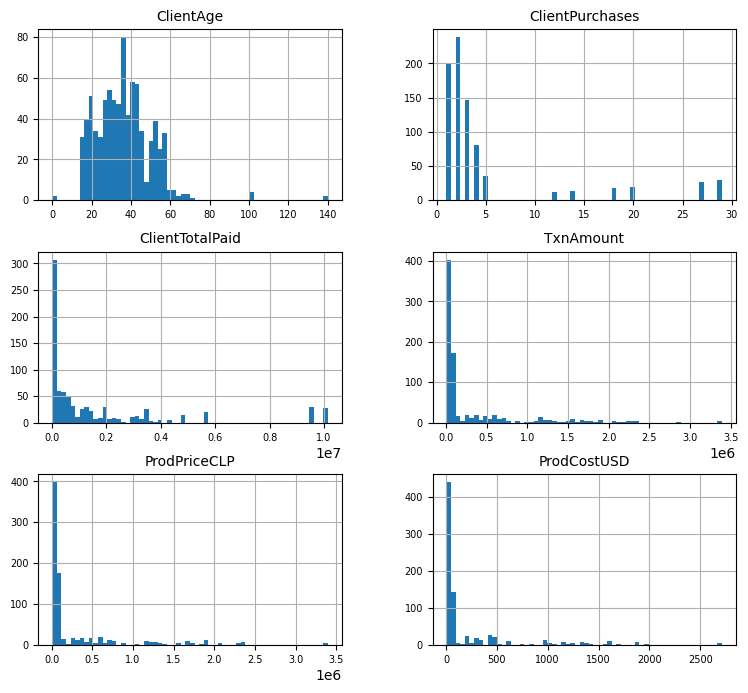

In [1858]:
axes = imputed_df.hist(column=columns_test, bins=60, figsize=(9, 8))
for row in axes:
    for ax in row:
        ax.title.set_fontsize(10)
        ax.tick_params(axis="both", labelsize=7)

La visualización de los histogramas confirma que `ClientAge` presenta una aproximación a campana simétrica, mientras que las variables operacionales/financieras poseen asimetría derecha pronunciada, contraviniendo la premisa del Z-score. En consecuencia, se considera adecuado el método Z-score para detectar outliers en ClientAge, y por ser la única variable que cumpliría los requisitos, se supondrá que este método estima mejor los límites de outliers en esta variable. Para el resto de variables financieras se priorizará el uso del método IQR.

A continuación, cumpliendo con la metodológica planteada, se analizarán los outliers candidatos detectados para cada variable, con objeto de tomar acción solo cuando se confirme que estos constituyen valores atípicos erróneos. Se usarán los resultados de ambos métodos para realizar análisis de los outliers, pero si se decide tomar acción sobre estos para alguna variable, se usarán los límites establecidos por el método de detección de outliers más adecuado, conforme a la distribución de la variable.

#### 4.2.5 Análisis de outliers: ClientAge

Inspección de anomalías etarias mediante ambos métodos.

In [1859]:
tools.inspect_outliers2(imputed_df, iqr_summary, z_score_summary, column_name="ClientAge", display_format="{:,.0f}")

--- Reporte de outliers para la variable ClientAge ---
Rango de la variable:          [0  a  140]
Límites de outliers (IQR):     [-1  a  71]
Límites de outliers (Z-Score): [-6  a  79]
Total de outliers (IQR):       6 (0.73%)
Total de outliers (Z-Score):   6 (0.73%)
------------------------------------------------------
Mostrando todos los outliers ordenados de menor a mayor:


Índice IQR,ClientAge (IQR),Índice Z-Score,ClientAge (Z-Score)
28,101,28,101
119,101,119,101
440,101,440,101
434,101,434,101
192,140,192,140
34,140,34,140


Ambos métodos estiman un límite superior razonable para outliers, aunque tal vez conservador, pero ambos métodos fallan en estimar un límite inferior que permita detectar los evidentes outliers existentes para las edades menores, reconocidos en la exploración inicial hecha en sección 2.2.1. En efecto, ambos métodos fallan en identificar como outlier las edades bajas para las que sería imposible realizar transacciones y, en particular, ambos métodos no detectan la edad futura imposible de 0 años.

Por la anterior falencia de ambos métodos, y con objeto de mantener la mayor cantidad de datos posibles, se ignorarán los límites estadísticos determinados por ambos métodos y se procederá a realizar "winsorización", seleccionando valores de edad límites con una lógica de negocio basada en viabilidad comercial. En consecuencia, se supondrá que estos límites de edad comprenden desde los 15 a 95 años.

In [1860]:
infant_threshold = 15
elder_threshold = 95

# Acción: Winsorización personalizada
cleaned_df = imputed_df.copy()
cleaned_df["ClientAge"] = cleaned_df["ClientAge"].clip(lower=infant_threshold, upper=elder_threshold)

# Para mantener consistencia, actualizamos ClientBirthdate en las filas que sufrieron la winsorización de su edad,
# recalculando sus valores mediante tools.calculate_birthdate

mask_changed_age = cleaned_df["ClientAge"] != imputed_df["ClientAge"]
cleaned_df.loc[mask_changed_age, "ClientBirthdate"] = tools.calculate_birthdate(
    cleaned_df.loc[mask_changed_age, "ClientAge"]
)

# Resumen de outliers basados en lógica de negocio
invalid_ages = imputed_df[(imputed_df["ClientAge"] < infant_threshold) | (imputed_df["ClientAge"] > elder_threshold)]
print(f"⚠️ Total de registros winsorizados por ser lógicamente inválidos en ClientAge: {len(invalid_ages)}")
print("Detalle de registros winsorizados:")
cleaned_df.loc[mask_changed_age, ["ClientBirthdate", "ClientAge"]].sort_values(by="ClientBirthdate")

⚠️ Total de registros winsorizados por ser lógicamente inválidos en ClientAge: 8
Detalle de registros winsorizados:


,ClientBirthdate,ClientAge
28,1931-03-10,95
119,1931-05-02,95
434,1931-07-28,95
192,1931-09-04,95
34,1931-11-18,95
440,1931-12-07,95
372,2011-06-11,15
360,2011-08-11,15


#### 4.2.6 Análisis de outliers: ClientPurchases

Revisión de outliers en frecuencia de compra.

In [1861]:
tools.inspect_outliers2(
    cleaned_df, iqr_summary, z_score_summary, column_name="ClientPurchases", display_format="{:,.0f}"
)

--- Reporte de outliers para la variable ClientPurchases ---
Rango de la variable:          [1  a  29]
Límites de outliers (IQR):     [-1  a  7]
Límites de outliers (Z-Score): [-17  a  27]
Total de outliers (IQR):       120 (14.65%)
Total de outliers (Z-Score):   29 (3.54%)
------------------------------------------------------------
Mostrando los 5 outliers más altos y más bajos, ordenados de menor a mayor:


Índice IQR,ClientPurchases (IQR),Índice Z-Score,ClientPurchases (Z-Score)
35,12,15,29
82,12,47,29
127,12,48,29
259,12,56,29
265,12,137,29
702,29,716,29
745,29,745,29
754,29,754,29
791,29,787,29
787,29,791,29


La presencia de volúmenes de hasta 29 transacciones anuales es completamente factible si consideramos la existencia de perfiles de clientes mayoristas o revendedores pyme dentro del marco del ecommerce.

Para determinar si los outliers detectados son valores posibles, se analizará la consistencia de los datos, verificando que la cantidad de transacciones por ClientId coincida con ClientPurchases para los outliers combinados (IQR + Z-Score) y que la cantidad de clientes únicos para los cuales ClientPurchases se detecta como outlier es relativamente pequeña (< 2%), dado que el foco del ecommerce no es mayorista.

In [1862]:
# Validamos que la cantidad de transacciones por ClientId coincida con ClientPurchases para los outliers combinados
# (IQR + Z-Score). Usamos función get_outlier_mask creada en módulo tools para obtener máscaras de outliers a partir de
# los resúmenes de IQR y Z-Score.
mask_iqr = tools.get_outlier_mask(cleaned_df, iqr_summary, "ClientPurchases")
mask_zscore = tools.get_outlier_mask(cleaned_df, z_score_summary, "ClientPurchases")
outliers_df = cleaned_df[mask_iqr | mask_zscore]

validation = outliers_df.groupby("ClientId").agg(
    TxnCount=("TxnId", "count"),
    ClientPurchases=("ClientPurchases", "first"),  # Es el mismo valor en todas las filas del cliente
)
validation["Match"] = validation["TxnCount"] == validation["ClientPurchases"]

# Resumen rápido
print(f"Clientes con outlier en ClientPurchases consistente: {validation['Match'].sum()} / {len(validation)}")
# Mostramos los que NO presentan consistencia (si los hay)
mismatches = validation[~validation["Match"]]

# Calculamos qué porcentaje de clientes únicos tienen ClientPurchases > límite superior IQR (peor caso)
clients_with_outlier_purchases = cleaned_df[mask_iqr]["ClientId"].nunique()
total_clients = cleaned_df["ClientId"].nunique()
pct_outliers = clients_with_outlier_purchases / total_clients * 100
max_pct_outlier = 2  # porcentaje de clientes outliers aceptados como "mayoristas"
print(
    f"Clientes únicos con ClientPurchases > límite superior IRQ: {clients_with_outlier_purchases} / {total_clients} ({pct_outliers:.1f}%)"
)

if not mismatches.empty:
    print(f"\n❌ En {len(mismatches)} clientes ClientPurchases NO es consistente:")
    display(mismatches)
else:
    print("\n✅ En todos los clientes ClientPurchases es consistente.")
if pct_outliers < max_pct_outlier:
    print(f"✅ Clientes únicos con ClientPurchases > límite superior IRQ < {max_pct_outlier}%.")
else:
    print(f"⚠️ Clientes únicos con ClientPurchases > límite superior IRQ ≥ {max_pct_outlier}%.")

Clientes con outlier en ClientPurchases consistente: 6 / 6
Clientes únicos con ClientPurchases > límite superior IRQ: 6 / 398 (1.5%)

✅ En todos los clientes ClientPurchases es consistente.
✅ Clientes únicos con ClientPurchases > límite superior IRQ < 2%.


**Conclusión**: Se acepta esta varianza en ClientPurchases, ratificando su factibilidad comercial.

#### 4.2.7 Análisis de outliers: ClientTotalPaid

Verificaremos proporciones monetarias.

In [1863]:
tools.inspect_outliers2(
    cleaned_df, iqr_summary, z_score_summary, column_name="ClientTotalPaid", display_format="{:,.0f}"
)

--- Reporte de outliers para la variable ClientTotalPaid ---
Rango de la variable:          [6,804  a  10,140,867]
Límites de outliers (IQR):     [-2,700,127  a  4,754,009]
Límites de outliers (Z-Score): [-6,154,076  a  9,407,534]
Total de outliers (IQR):       90 (10.99%)
Total de outliers (Z-Score):   56 (6.84%)
------------------------------------------------------------
Mostrando los 5 outliers más altos y más bajos, ordenados de menor a mayor:


Índice IQR,ClientTotalPaid (IQR),Índice Z-Score,ClientTotalPaid (Z-Score)
14,"4,827,427",47,"9,518,199"
65,"4,827,427",15,"9,518,199"
220,"4,827,427",56,"9,518,199"
195,"4,827,427",48,"9,518,199"
199,"4,827,427",137,"9,518,199"
578,"10,140,867",688,"10,140,867"
647,"10,140,867",687,"10,140,867"
637,"10,140,867",602,"10,140,867"
602,"10,140,867",637,"10,140,867"
782,"10,140,867",782,"10,140,867"


De manera idéntica al caso anterior, niveles abultados de gasto son plausibles en ecosistemas donde convergen usuarios regulares e intermediarios mayoristas.

Comprobaremos la integridad de los datos, validando que la sumatoria interna explícita de `TxnAmount` iguale al `ClientTotalPaid` individual y que la cantidad de clientes únicos para los cuales ClientTotalPaid se detecta como outlier es relativamente pequeña, dado que el foco del ecommerce no es mayorista.

In [1864]:
# Validamos que la suma de TxnAmount por ClientId coincida con ClientTotalPaid para los outliers combinados
# (IQR + Z-Score).
mask_iqr = tools.get_outlier_mask(cleaned_df, iqr_summary, "ClientTotalPaid")
mask_zscore = tools.get_outlier_mask(cleaned_df, z_score_summary, "ClientTotalPaid")
outliers_df = cleaned_df[mask_iqr | mask_zscore]

validation = outliers_df.groupby("ClientId").agg(
    SumTxnAmount=("TxnAmount", "sum"),
    ClientTotalPaid=("ClientTotalPaid", "first"),  # Es el mismo valor en todas las filas del cliente
)
validation["Match"] = validation["SumTxnAmount"] == validation["ClientTotalPaid"]

# Resumen rápido
print(f"Clientes con outlier en ClientTotalPaid consistente: {validation['Match'].sum()} / {len(validation)}")
# Mostramos los que NO coinciden (si los hay)
mismatches = validation[~validation["Match"]]

# Calculamos qué porcentaje de clientes únicos tienen ClientTotalPaid > límite superior IQR (peor caso)
clients_with_outlier_purchases = cleaned_df[mask_iqr]["ClientId"].nunique()
pct_outliers = clients_with_outlier_purchases / total_clients * 100
max_pct_outlier = 2  # porcentaje de clientes outliers aceptados como "mayoristas"
print(
    f"Clientes únicos con ClientTotalPaid > límite superior IRQ: {clients_with_outlier_purchases} / {total_clients} ({pct_outliers:.1f}%)"
)

if not mismatches.empty:
    print(f"\n❌ En {len(mismatches)} clientes ClientTotalPaid NO es consistente:")
    display(mismatches)
else:
    print("\n✅ En todos los clientes ClientTotalPaid es consistente.")

if pct_outliers < max_pct_outlier:
    print(f"✅ Clientes únicos con ClientTotalPaid > límite superior IRQ < {max_pct_outlier}%.")
else:
    print(f"⚠️ Clientes únicos con ClientTotalPaid > límite superior IRQ ≥ {max_pct_outlier}%.")

Clientes con outlier en ClientTotalPaid consistente: 4 / 4
Clientes únicos con ClientTotalPaid > límite superior IRQ: 4 / 398 (1.0%)

✅ En todos los clientes ClientTotalPaid es consistente.
✅ Clientes únicos con ClientTotalPaid > límite superior IRQ < 2%.


**Conclusión**: Consideramos válido el espectro detectado como atípico para montos totales.

#### 4.2.8 Análisis de outliers: TxnAmount

Se inspeccionan los outliers para TxnAmount obtenidos con métodos de IQR y Z-Score, junto a algunas columnas relevantes para el análisis.

In [1865]:
tools.inspect_outliers(
    cleaned_df,
    iqr_summary,
    column_name="TxnAmount",
    columns_to_show=["TxnAmount", "ProdPriceCLP", "ProdCategory"],
    display_format="{:,.0f}",
)

--- Reporte de outliers (IQR) para la variable TxnAmount ---
Rango de la variable: [6,505  a  3,395,528]
Límites de outliers:  [-361,744  a  686,932]
Total de outliers:    115 (14.04%)
------------------------------------------------------------
Mostrando los 5 outliers más altos y más bajos, ordenados de menor a mayor:


Índice,TxnAmount,ProdPriceCLP,ProdCategory
50,"693,675","693,675",Monitores
132,"693,675","693,675",Monitores
545,"693,675","693,675",Monitores
233,"706,452","743,634",Computadores y Tablets
584,"706,452","743,634",Computadores y Tablets
142,"2,886,199","3,395,528",Computadores y Tablets
183,"3,395,528","3,395,528",Computadores y Tablets
659,"3,395,528","3,395,528",Computadores y Tablets
596,"3,395,528","3,395,528",Computadores y Tablets
753,"3,395,528","3,395,528",Computadores y Tablets


In [1866]:
tools.inspect_outliers(
    cleaned_df,
    z_score_summary,
    column_name="TxnAmount",
    columns_to_show=["TxnAmount", "ProdPriceCLP", "ProdCategory"],
    display_format="{:,.0f}",
)

--- Reporte de outliers (Z-Score) para la variable TxnAmount ---
Rango de la variable: [6,505  a  3,395,528]
Límites de outliers:  [-1,364,162  a  1,990,397]
Total de outliers:    21 (2.56%)
----------------------------------------------------------------
Mostrando los 5 outliers más altos y más bajos, ordenados de menor a mayor:


Índice,TxnAmount,ProdPriceCLP,ProdCategory
166,"2,090,332","2,090,332",Computadores y Tablets
630,"2,090,332","2,090,332",Computadores y Tablets
638,"2,090,332","2,090,332",Computadores y Tablets
75,"2,109,169","2,343,521",Computadores y Tablets
620,"2,167,266","2,281,333",Computadores y Tablets
49,"2,886,199","3,395,528",Computadores y Tablets
183,"3,395,528","3,395,528",Computadores y Tablets
596,"3,395,528","3,395,528",Computadores y Tablets
659,"3,395,528","3,395,528",Computadores y Tablets
753,"3,395,528","3,395,528",Computadores y Tablets


Los valores de TxnAmount para los que se detecta outliers son plausibles porque sabemos que algunos de los productos tecnológicos vendidos en el ecommerce alcanzan estos valores.

Conociendo la lógica implícita de que una compra registra un producto, permitiendo un descuento de hasta 20%, el "Monto cobrado (`TxnAmount`)" jamás superará su contraparte "(`ProdPriceCLP`)" ni será subvalorado por sobre su umbral de descuento. Confirmaremos programáticamente que la operación cumpla con esta regla estricta dentro de las categorías de producto lógicas ("Computadores y Tablets", "Monitores") que contienen productos que alcanzan este rango de precios.

In [1867]:
# Validamos que TxnAmount esté entre el 80% y el 100% de ProdPriceCLP.
ratio = (cleaned_df["TxnAmount"] / cleaned_df["ProdPriceCLP"]).round(3)
matches = ((ratio >= 0.8) & (ratio <= 1.0)).sum()
mismatches = len(cleaned_df) - matches
if mismatches == 0:
    print("✅ Todas las transacciones cumplen: 0.8 × ProdPriceCLP ≤ TxnAmount ≤ ProdPriceCLP")
else:
    print(f"\n❌ {mismatches} transacciones NO cumplen la condición.")

# Máscara de transacciones para las cuales TxnAmount es outlier según IQR (peor caso)
mask_iqr = tools.get_outlier_mask(cleaned_df, iqr_summary, "TxnAmount")

# Verificamos que todas las transacciones filtradas por mask_iqr tienen ProdCategory en el conjunto esperado
expected_categories = {"Computadores y Tablets", "Monitores"}
outlier_categories = cleaned_df.loc[mask_iqr, "ProdCategory"].unique()
unexpected = set(outlier_categories) - expected_categories
if not unexpected:
    print("✅ Todas las transacciones outlier de TxnAmount pertenecen a las categorías esperadas.")
else:
    print(f"⚠️ Se encontraron categorías inesperadas: {unexpected}")

✅ Todas las transacciones cumplen: 0.8 × ProdPriceCLP ≤ TxnAmount ≤ ProdPriceCLP
✅ Todas las transacciones outlier de TxnAmount pertenecen a las categorías esperadas.


**Conclusión**: Aceptamos los outliers de `TxnAmount` porque constituyen valores posibles.

#### 4.2.9 Análisis de outliers: ProdPriceCLP
Se inspeccionan los outliers para ProdPriceCLP junto a algunas columnas relevantes para el análisis.

In [1868]:
tools.inspect_outliers(
    cleaned_df,
    iqr_summary,
    column_name="ProdPriceCLP",
    columns_to_show=["ProdPriceCLP", "ProdName", "ProdCategory"],
    rows=3,
    display_format="{:,.0f}",
)

--- Reporte de outliers (IQR) para la variable ProdPriceCLP ---
Rango de la variable: [7,162  a  3,395,528]
Límites de outliers:  [-358,910  a  685,230]
Total de outliers:    123 (15.02%)
---------------------------------------------------------------
Mostrando los 3 outliers más altos y más bajos, ordenados de menor a mayor:


Índice,ProdPriceCLP,ProdName,ProdCategory
50,"693,675",Monitor 10,Monitores
132,"693,675",Monitor 10,Monitores
344,"693,675",Monitor 10,Monitores
596,"3,395,528",Notebook 6,Computadores y Tablets
659,"3,395,528",Notebook 6,Computadores y Tablets
753,"3,395,528",Notebook 6,Computadores y Tablets


In [1869]:
tools.inspect_outliers(
    cleaned_df,
    z_score_summary,
    column_name="ProdPriceCLP",
    columns_to_show=["ProdPriceCLP", "ProdName", "ProdCategory"],
    rows=3,
    display_format="{:,.0f}",
)

--- Reporte de outliers (Z-Score) para la variable ProdPriceCLP ---
Rango de la variable: [7,162  a  3,395,528]
Límites de outliers:  [-1,409,427  a  2,053,393]
Total de outliers:    22 (2.69%)
-------------------------------------------------------------------
Mostrando los 3 outliers más altos y más bajos, ordenados de menor a mayor:


Índice,ProdPriceCLP,ProdName,ProdCategory
166,"2,090,332",PC 9,Computadores y Tablets
169,"2,090,332",PC 9,Computadores y Tablets
638,"2,090,332",PC 9,Computadores y Tablets
142,"3,395,528",Notebook 6,Computadores y Tablets
659,"3,395,528",Notebook 6,Computadores y Tablets
753,"3,395,528",Notebook 6,Computadores y Tablets


Los valores de ProdPriceCLP para los que se detecta outliers son plausibles porque sabemos que algunos de los productos tecnológicos vendidos en el ecommerce alcanzan estos valores.

Como ya se indicó, sabemos que las categorías de productos "Computadores y Tablets" y "Monitores" son las 2 categorías de productos en las que se alcanzan precios como los detectados como outliers. A simple vista, vemos que se cumple esta condición para la muestra de ourliers explorados. Para decidir si aceptar o no cada uno de los outliers detectados, se validará si se cumple esta condición.

In [1870]:
# Máscara de transacciones para las cuales ProdPriceCLP es outlier según IQR (peor caso)
mask_iqr = tools.get_outlier_mask(cleaned_df, iqr_summary, "ProdPriceCLP")

# Verificamos que todas las transacciones filtradas por mask_iqr tienen ProdCategory en el conjunto esperado
expected_categories = {"Computadores y Tablets", "Monitores"}
outlier_categories = cleaned_df.loc[mask_iqr, "ProdCategory"].unique()
unexpected = set(outlier_categories) - expected_categories
if not unexpected:
    print("✅ Todas las transacciones outlier de ProdPriceCLP pertenecen a las categorías esperadas.")
else:
    print(f"⚠️ Se encontraron transacciones outlier de ProdPriceCLP en categorías inesperadas: {unexpected}")

✅ Todas las transacciones outlier de ProdPriceCLP pertenecen a las categorías esperadas.


**Conclusión**: ignoraremos los outliers detectados en ProdPriceCLP.

#### 4.2.10 Análisis de outliers: ProdCostUSD

Se inspeccionan los outliers para ProdCostUSD, junto a algunas columnas relevantes para el análisis.

In [1871]:
tools.inspect_outliers(
    cleaned_df,
    iqr_summary,
    column_name="ProdCostUSD",
    columns_to_show=["ProdCostUSD", "ProdPriceCLP", "ProdCategory"],
    rows=3,
    display_format="{:,.0f}",
)

--- Reporte de outliers (IQR) para la variable ProdCostUSD ---
Rango de la variable: [4  a  2,715]
Límites de outliers:  [-288  a  529]
Total de outliers:    111 (13.55%)
--------------------------------------------------------------
Mostrando los 3 outliers más altos y más bajos, ordenados de menor a mayor:


Índice,ProdCostUSD,ProdPriceCLP,ProdCategory
47,611,"743,634",Computadores y Tablets
233,611,"743,634",Computadores y Tablets
668,611,"743,634",Computadores y Tablets
659,"2,715","3,395,528",Computadores y Tablets
596,"2,715","3,395,528",Computadores y Tablets
753,"2,715","3,395,528",Computadores y Tablets


In [1872]:
tools.inspect_outliers(
    cleaned_df,
    z_score_summary,
    column_name="ProdCostUSD",
    columns_to_show=["ProdCostUSD", "ProdPriceCLP", "ProdCategory"],
    rows=3,
    display_format="{:,.0f}",
)

--- Reporte de outliers (Z-Score) para la variable ProdCostUSD ---
Rango de la variable: [4  a  2,715]
Límites de outliers:  [-1,171  a  1,674]
Total de outliers:    22 (2.69%)
------------------------------------------------------------------
Mostrando los 3 outliers más altos y más bajos, ordenados de menor a mayor:


Índice,ProdCostUSD,ProdPriceCLP,ProdCategory
166,"1,711","2,090,332",Computadores y Tablets
169,"1,711","2,090,332",Computadores y Tablets
638,"1,711","2,090,332",Computadores y Tablets
142,"2,715","3,395,528",Computadores y Tablets
659,"2,715","3,395,528",Computadores y Tablets
753,"2,715","3,395,528",Computadores y Tablets


La muestra de outliers para `ProdCostUSD` evidencia valores igualmente plausibles dentro de categorías tecnológicas. Como en el caso anterior de `ProdPriceCLP`, si tras la validación cruzada no emergen imposibilidades lógicas, conservaremos los registros.

En este caso, si para todos los productos se verificó que el precio es posible, basta con verificar el requisito físico para cualquier producto transable que exige que su costo operativo sea estrictamente inferior a su precio de venta final. Para alinear las divisas, calcularemos el costo equivalente en CLP asumiendo un tipo de cambio constante de 944 pesos por dólar (promedio referencial estimado para 2024, año en el que se efectuaron las compras del inventario).

In [1873]:
# Calculamos aproximadamente la razón ProdCostCLP / ProdPriceCLP para outliers combinados (IQR + Z-Score), considerando
# un valor de dolar de 944, que es el promedio del año 2024.
mask_iqr = tools.get_outlier_mask(cleaned_df, iqr_summary, "ProdCostUSD")
mask_zscore = tools.get_outlier_mask(cleaned_df, z_score_summary, "ProdCostUSD")
outliers_df = cleaned_df[mask_iqr | mask_zscore]
cost_to_price = 944 * outliers_df["ProdCostUSD"] / outliers_df["ProdPriceCLP"]
min_cost_to_price = cost_to_price.min()
max_cost_to_price = cost_to_price.max()

print(f"{cost_to_price.min() : .2f} < (ProdCostCLP / ProdPriceCLP) < {cost_to_price.max() : .2f}")
if max_cost_to_price < 1:
    print("\n✅ Para todos los productos vendidos con outlier en ProdCostUSD: ProdCostCLP < ProdPriceCLP.")
else:
    print(f"\n❌ Para algunos productos con outlier en ProdCostUSD: ProdCostCLP ≥ ProdPriceCLP")

 0.72 < (ProdCostCLP / ProdPriceCLP) <  0.83

✅ Para todos los productos vendidos con outlier en ProdCostUSD: ProdCostCLP < ProdPriceCLP.


**Conclusión**: Categorizamos los outliers de `ProdCostUSD` como válidos dada la viabilidad comercial de la métrica de cruce.

#### 4.2.11 El dilema del sesgo en la detección de outliers por cambio en la granularidad de los datos

Al finalizar el análisis de outliers, y al revisar nuevamente las estadísticas descriptivas del dataframe fusionado (sección 4.2.2), observé que en muchas variables la media, la desviación estándar y la mediana difieren significativamente respecto a los valores obtenidos en la exploración inicial (sección 2.2) de los dataframes originales. Por ejemplo, la media de ClientPurchases pasó de 1.4 a 5.2 tras la fusión de datos.

Comprender por qué se producen estas variaciones es fundamental, ya que las estadísticas descriptivas sirven de base para los métodos de detección de valores atípicos, como IQR y Z‑Score. Si se calculan sin considerar el cambio de granularidad, los resultados pueden inducir sesgos o interpretaciones erróneas.

Analizando la fusión realizada en la sección 3.3, se aprecia que esta operación modificó la granularidad del conjunto de datos: antes cada registro representaba un cliente, mientras que en el dataframe fusionado cada registro representa una transacción. Solo los clientes con compras aparecen en el nuevo dataframe, y cada una de sus transacciones genera una fila independiente que combina información tanto del cliente como del producto adquirido. Así, un mismo cliente o producto puede aparecer múltiples veces, dependiendo del número de transacciones.

Esta variación en la granularidad explica los cambios observados en las estadísticas descriptivas, ya que las observaciones, y por tanto las ponderaciones de cada entidad, se repiten en función de su frecuencia transaccional. En consecuencia, para el análisis de outliers resulta esencial definir, según el propósito del estudio y la naturaleza de cada variable, si las estadísticas deben obtenerse directamente del dataframe fusionado o si conviene recalcularlas sobre datos agregados a un nivel más adecuado (por ejemplo, por cliente o por producto). No existe una única respuesta válida; la elección depende del significado analítico de la variable y de los objetivos específicos del análisis.

##### Ejemplos de posibles escenarios y acciones requeridas

- En el caso de las variables numéricas ClientPurchases y ClientTotalPaid, originadas en el dataframe de clientes, la aparición de estas variables en cada fila del dataframe fusionado implica que en sus estadísticas se sobrerrepresentará la cantidad de compras y totales pagados por los clientes que realizaron varias compras, y en particular se corre el riesgo de sobrerrepresentar a una pequeña cantidad de clientes mayoristas. Un sesgo similar se produciría en general en el dataframe fusionado para cada una de las variables que cuantifiquen acumulación en los dataframes originales. En nuestro problema en particular, para evitar introducir el sesgo que desplazaría artificialmente los límites en la detección de outliers en estas variables, se debería quitar previamente las filas duplicadas en ClientId en el dataframe fusionado.
- Para la variable ClientAge podríamos considerar dos escenarios. Si queremos estudiar la edad de los clientes detrás de cada venta, por ejemplo para tomar decisiones operativas por transacción, deberíamos considerar las estadísticas para el dataframe fusionado. Si queremos estudiar la edad de los clientes de nuestra cartera de clientes activos (clientes únicos que han comprado), por ejemplo para un análisis demográfico de segmentación de usuarios, deberíamos considerar las estadísticas para el dataframe fusionado, previamente habiendo removido los duplicados en ClientId. El primer caso pondera la edad por volumen de compra. El segundo caso pondera a cada comprador por igual.
- En el caso de las variables numéricas ProdPriceCLP y ProdCostUSD, originadas en el dataframe de productos, también podríamos considerar dos escenarios. Si queremos estudiar el precio/costo de los artículos vendidos, por ejemplo para hacer análisis transaccionales y de proyecciones, deberíamos considerar las estadísticas para el dataframe fusionado. Si queremos estudiar el precio/costo de los productos en nuestra oferta comercial activa, por ejemplo para realizar análisis sobre el posicionamiento en el mercado o estrategia de precios global, deberíamos considerar las estadísticas para el dataframe fusionado, previamente habiendo removido los duplicados en ProductName. El primer caso pondera precios y costos por popularidad o éxito de ventas. El segundo caso pondera precios asumiendo que se tiene una vitrina estática, evaluando simplemente la diversidad de oferta.
- Aunque en este proyecto no se abordó formalmente la detección de outliers en variables categóricas, el sesgo inducido por el cambio de granularidad también puede afectar el análisis de “outliers categóricos”. Por ejemplo, al estudiar la distribución de la variable ClientCity, podemos querer describir la base de clientes activos o bien la distribución de transacciones por ciudad. En el primer caso es necesario eliminar duplicados por ClientId para que cada cliente cuente una sola vez; en el segundo caso es pertinente conservar todas las filas para que las ciudades se ponderen por volumen de compra. Esta misma lógica debe evaluarse caso a caso para decidir si resulta apropiado depurar duplicados antes de estudiar frecuencias o categorías inusuales.
- Finalmente, si el objetivo es analizar outliers en variables definidas sobre el catálogo completo de productos disponibles (no solo los vendidos) o sobre la totalidad de clientes registrados (no solo compradores), ya no basta con ajustar el dataframe fusionado. En estos escenarios es necesario trabajar directamente con los dataframes originales, ya que, a partir de la fusión descrita en la sección 3.3, solo se conservan los registros de productos vendidos y de clientes que han realizado al menos una compra.

En base al análisis previo, al haber realizado la detección de outliers directamente sobre el dataframe fusionado, en todos los casos, se supuso que interesa enfocar el análisis desde el punto de vista de las transacciones. Sin embargo, como comentamos, para analizar los outliers en las variables ClientPurchases y ClientTotalPaid, en rigor se debería remover previamente duplicados de filas del dataframe fusionado en base a ClientId. No repetiremos el análisis de outliers haciendo esta corrección porque, debido a los criterios empleados para validar como posibles todos los valores que se identificaron como outliers, el resultado no cambiaría.

##### Cuantificando el impacto del sesgo en la detección de outliers por cambio en la granularidad de los datos

Como ejercicio didáctico, con el propósito de cuantificar el posible impacto del sesgo por cambio en la granularidad de los datos para los límites estimados por los métodos IQR y Z-Score, se calculará el cambio porcentual que experimentan las estadísticas descriptivas usadas en estos métodos, comparando las estadísticas descriptivas obtenidas en el dataframe fusionado, con y sin eliminación de filas duplicadas, para las variables de interés. El error porcentual en los límites estimados para los cálculos de outliers, cuando no se calculen apropiadamente las estadísticas según el objetivo de análisis, sera proporcional a estas variaciones. Para evaluar el impacto de considerar las estadísticas inapropiadas en todos los posibles escenarios analizados previamente, se considerarán los casos en que se remueven o no del dataframe fusionado las filas duplicadas en ClientId y en ProductName. Se evaluarán las estadísticas para todas las variables previamente analizadas, posiblemente afectadas por remover estos duplicados. 

Por la estructura del dataframe fusionado, orientado a transacciones únicas, no esperamos que las variables derivadas del dataframe original de transacciones se vea afectado por remoción de filas duplicadas en base a ClientId o ProductName, ni tampoco cuando se remuevan filas duplicadas en base a TxnId. Sin embargo, para generalizar más el ejercicios, también se considerará el caso de la remoción o no de filas duplicadas en base a TxnId.

In [1874]:
# Cuantificamos cuanto es el cambio porcentual de las estadísticas descriptivas de las variables de interés después de
# fusionar dataframes, para los casos de remover o no duplicados en en ClientId o ProductName. Para esto se creo la
# función `compare_granularity_bias` en el módulo tools
tools.compare_granularity_bias(cleaned_df)

Column,Origin,mean Δ%,std Δ%,median Δ%,min Δ%,max Δ%
ClientAge,clients_df,+2.1%,+10.1%,+5.9%,+0.0%,+0.0%
ClientPurchases,clients_df,+153.2%,+191.7%,+0.0%,+0.0%,+0.0%
ClientTotalPaid,clients_df,+157.4%,+131.2%,+271.3%,+0.0%,+0.0%
TxnAmount,transactions_df,+1.5%,+1.3%,+6.1%,+0.0%,+0.0%
ProdPriceCLP,products_df,-43.5%,-19.6%,-51.1%,+0.0%,+0.0%
ProdCostUSD,products_df,-44.7%,-19.6%,-58.8%,+0.0%,+0.0%


Se aprecia que el posible error en el cálculo de las estadísticas descriptivas empleadas para calcular los límites que definen los outliers, cuando se remueven o no duplicados erróneamente según el objetivo de análisis, es muy significativo en general. En consecuencia, es muy relevante definir claramente los objetivos de análisis antes de estimar outliers, para establecer en cada caso como se deben calcular las estadísticas correspondientes. Se aprecia en la tabla de comparación que la diferencia porcentual es mayor para las variables que representan acumulación (ClientPurchases, ClientTotalPaid) y es menor, pero no despreciable, para la variable que permanece constante entre transacciones (ClientAge).

Observamos que para la variable TxnAmount, contrariamente a lo que supusimos, sus estadísticas descriptivas cambiaron un poco cuando se removieron filas duplicadas en base a ClientId, ProductName o TxnId. Esto es una anomalía, porque no se esperaba que con cualquiera de las remociones anteriores se removieran filas asociadas a transacciones con único TxnId y nos hace sospechar que en el dataframe de transacciones originales existen filas duplicas. En efecto, como construimos los datos, sabemos que es así. Para confirmar que nuestra suposición para TxnAmount antes de calcular la tabla era correcta, repetiremos los cálculos después de remover las "posibles" filas duplicadas en TxnId.

In [1875]:
tools.compare_granularity_bias(cleaned_df.drop_duplicates(subset="TxnId"))

Column,Origin,mean Δ%,std Δ%,median Δ%,min Δ%,max Δ%
ClientAge,clients_df,+2.1%,+10.0%,+5.9%,+0.0%,+0.0%
ClientPurchases,clients_df,+153.8%,+192.4%,+0.0%,+0.0%,+0.0%
ClientTotalPaid,clients_df,+157.4%,+131.7%,+271.3%,+0.0%,+0.0%
TxnAmount,transactions_df,+0.0%,+0.0%,+0.0%,+0.0%,+0.0%
ProdPriceCLP,products_df,-44.4%,-21.0%,-58.5%,+0.0%,+0.0%
ProdCostUSD,products_df,-45.6%,-21.0%,-65.2%,+0.0%,+0.0%


El último resultado confirma que para nuestro dataframe fusionado, enfocado en transacciones, las estadísticas descriptivas de las variables originadas en el dataframe de transacciones no se ven afectadas por la remoción de filas duplicadas en ClientId, ProductName o TxnId. Sin embargo, las estadísticas descriptivas, y en consecuencia las estimaciones de outliers, de las variables originadas en los dataframes de clientes y productos sí se ven afectadas significativamente por la remoción de filas duplicadas en ClientId o ProductName, ratificando la necesidad de calcular apropiadamente las estadísticas según el objetivo de análisis.

### 4.3 Guarda datos limpios de valores perdidos y outliers espurios

In [1876]:
cleaned_df.to_parquet(data_dir / "4_cleaned_df.parquet")

# Elimina DataFrames auxiliares creados en esta sección para simular que siguientes secciones comienzan desde cero
del cleaned_df, merged_df, imputed_df
gc.collect()

36092

## <a id="lesson5" name="lesson5"></a>5. Data Wrangling

### 5.1 Carga de datos libres de valores perdidos y outliers espurios

In [1877]:
cleaned_df = pd.read_parquet(data_dir / "4_cleaned_df.parquet")

### 5.2 Eliminación de registros duplicados

En la sección 4.2.11, ya detectamos indirectamente que en los datos existen duplicados no deseados en la columna TxnId. Buscamos formalmente todos los registros duplicados y luego los eliminamos, manteniendo únicamente el primer registro.

In [1878]:
uniques_df = cleaned_df.drop_duplicates(keep="first")
print("Número de registros duplicados eliminados:", cleaned_df.duplicated().sum() - uniques_df.duplicated().sum())

Número de registros duplicados eliminados: 4


### 5.3 Crear nuevas columnas calculadas

#### 5.3.1 Creación de columnas históricas ClientPurchasesAccum y ClientTotalPaidAccum

En el dataset original, las columnas ClientPurchases y ClientTotalPaid actúan como una "fotografía final" que muestra el estado del cliente en el periodo más reciente, registrándose con redundancia en el dataframe fusionado, al ser constantes por cliente. Para un análisis de comportamiento real, puede ser más valioso observar la película completa del crecimiento de cada cliente en el tiempo. Esto proporcionaría más capacidad para hacer predicciones sobre comportamientos en el tiempo. Por esto, se transformarán los datos estáticos ClientPurchases y ClientTotalPaid en métricas dinámicas acumuladas en el tiempo, calculando ClientPurchasesAccum y ClientTotalPaidAccum respectivamente.

In [1879]:
# Ordena el DataFrame por cliente y luego por fecha para que los cálculos acumulativos tengan sentido cronológico.
uniques_df = uniques_df.sort_values(by=["ClientId", "TxnDate"])

# Recalcula ClientPurchases como un recuento acumulado por cliente.
# Utiliza cumcount() + 1 para comenzar desde 1 en lugar de 0.
uniques_df["ClientPurchasesAccum"] = uniques_df.groupby("ClientId").cumcount() + 1

# Recalcula ClientTotalPaid como una suma acumulada de TxnAmount por cliente.
uniques_df["ClientTotalPaidAccum"] = (uniques_df.groupby("ClientId")["TxnAmount"].cumsum()).astype(int)

In [1898]:
# Verificamos consistencia de las nuevas columnas calculadas para un cliente aleatorio
random_client_id = uniques_df["ClientId"].sample(n=1).iloc[0]
columns_to_show = [
    "TxnDate",
    "ClientId",
    "ClientPurchasesAccum",
    "ClientPurchases",
    "ClientTotalPaidAccum",
    "ClientTotalPaid",
]
print(f"Datos para ClientId: {random_client_id}")
display(uniques_df.loc[uniques_df["ClientId"] == random_client_id, columns_to_show])

Datos para ClientId: 117


,TxnDate,ClientId,ClientPurchasesAccum,ClientPurchases,ClientTotalPaidAccum,ClientTotalPaid
649,2025-02-05,117,1,5,1460530,4257791
120,2025-07-17,117,2,5,1537471,4257791
410,2025-07-24,117,3,5,1560132,4257791
66,2025-07-30,117,4,5,3097532,4257791
679,2025-10-08,117,5,5,4257791,4257791


#### 5.3.2 Creación de columna derivada: TxnDateIsWeekend

Agregamos columna que clasifica si una fecha de compra es fin de semana o no usando función lambda y apply.

In [1881]:
uniques_df["TxnDateIsWeekend"] = uniques_df["TxnDate"].apply(lambda x: x.weekday() >= 5)

#### 5.3.3 Creación de columna ProdInventoryHoldTime

En base a la diferencia entre TxnDate y ProdPurchaseDate se calculará cuanto tiempo estuvo el producto "en estantería" antes de venderse. Esta sería una variable más fácil de interpretar que las fechas, en la cual se podría buscar outliers y que podría utilizarse en algoritmos que solo procesan números.

In [1882]:
uniques_df["ProdInventoryHoldTime"] = (
    pd.to_datetime(uniques_df["TxnDate"]) - pd.to_datetime(uniques_df["ProdPurchaseDate"])
).dt.days

#### 5.3.4 Discretización de columna ClientAge

Transformamos ClientAge en una variable categórica.

In [1883]:
# Definimos 4 categorías de edad. Por la winsorización previa de ClientAge, el rango está entre 0 y 95.
age_labels = ["Adolescente", "Joven adulto", "Adulto", "Mayor"]
uniques_df["ClientAgeGroup"] = pd.cut(uniques_df["ClientAge"], bins=[0, 18, 35, 60, 100], labels=age_labels)

### 5.4 Transformación de tipos de datos

Con objeto de optimizar el uso de memoria y el rendimiento en los procesamientos posteriores, se reducirá la precisión de los datos (downcasting) de todos los tipos de datos numéricos, al tipo con la menor precisión que es suficiente para representar cada variable.

In [1884]:
# Exploramos los tipos para decidir que transformaciones realizar
uniques_df.dtypes

TxnId                             int64
ClientId                          int64
ProdName                            str
TxnAmount                       float64
TxnDate                  datetime64[us]
ClientName                          str
ClientCity                          str
ClientBirthdate          datetime64[us]
ClientPurchases                   int64
ClientTotalPaid                   int64
ProdId                            int64
ProdCategory                        str
ProdPriceCLP                      int64
ProdCostUSD                     float64
ProdPurchaseDate         datetime64[us]
ClientAge                         Int64
ClientPurchasesAccum              int64
ClientTotalPaidAccum              int64
TxnDateIsWeekend                   bool
ProdInventoryHoldTime             int64
ClientAgeGroup                 category
dtype: object

In [1885]:
# Realizamos downcast óptimo de los tipos numéricos int64 y float64 usando la capacidad incorporada en to_numeric
def optimize_memory(df):
    for col in df.columns:
        # Validamos usando las funciones de pandas para abarcar tipos numéricos estándar (int64, float64)
        # y nullables (Int64, Float64).
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df


optimized_df = optimize_memory(uniques_df.copy())

# Cuantificamos el porcentaje de ahorro de memoria con la transformación de tipos
memory_use = uniques_df.memory_usage().sum()
new_memory_use = optimized_df.memory_usage().sum()
print(f"✅ Ahorro de memoria con la optimización de tipos: {(memory_use - new_memory_use)* 100 / memory_use:0.1f} %")

# Seleccionamos únicamente las columnas numéricas para un resumen comparativo
numeric_cols = uniques_df.select_dtypes(include="number")
opt_numeric_cols = optimized_df[numeric_cols.columns]

# Comparamos los tipos numéricos originales y los nuevos, y verificamos que se preserva la representación de los datos extremos
summary_df = pd.DataFrame(
    {
        "old Dtype": numeric_cols.dtypes,
        "new Dtype": opt_numeric_cols.dtypes,
        "Min": numeric_cols.min(),
        "Max": numeric_cols.max(),
        "Δ Min": abs(numeric_cols.min() - opt_numeric_cols.min()),
        "Δ Max": abs(numeric_cols.max() - opt_numeric_cols.max()),
    }
)
print("Comparación de tipos numéricos optimizados")
display(summary_df)

✅ Ahorro de memoria con la optimización de tipos: 31.4 %
Comparación de tipos numéricos optimizados


,old Dtype,new Dtype,Min,Max,Δ Min,Δ Max
TxnId,int64,int16,1.0,815.0,0.0,0.0
ClientId,int64,int16,1.0,600.0,0.0,0.0
TxnAmount,float64,float32,6505.0,3395528.0,0.0,0.0
ClientPurchases,int64,int8,1.0,29.0,0.0,0.0
ClientTotalPaid,int64,int32,6804.0,10140867.0,0.0,0.0
ProdId,int64,int8,1.0,105.0,0.0,0.0
ProdPriceCLP,int64,int32,7162.0,3395528.0,0.0,0.0
ProdCostUSD,float64,float32,3.75,2714.56,0.0,0.000059
ClientAge,Int64,Int8,15.0,95.0,0.0,0.0
ClientPurchasesAccum,int64,int8,1.0,29.0,0.0,0.0


### 5.5 Guardar DataFrame optimizado

In [1886]:
optimized_df.to_parquet(data_dir / "5_optimized_df.parquet")

# Elimina DataFrames auxiliares creados en esta sección para simular que siguientes secciones comienzan desde cero
# del uniques_df, cleaned_df, optimized_df, numeric_cols, opt_numeric_cols
# gc.collect()

## <a id="lesson6" name="lesson6"></a>6. Agrupamiento y pivoteo de datos

### 6.1 Carga de datos transformados

In [1887]:
wrangled_df = pd.read_parquet(data_dir / "5_optimized_df.parquet")

### 6.2 Restructuración y combinación de fuentes de datos

En la sección 3.2.3 se extrajo desde la web del SII la tabla del valor del dólar para el año 2024, con el objeto de convertir el costo de los productos de USD a CLP. Lo cual se realiza a continuación.

#### 6.2.1 Despivotea tabla del valor de USD y crea tabla lookup de conversión

In [1888]:
# Carga de tabla complementaria con conversión de USD a CLP del 2024
try:
    dolar_clp_table_df = pd.read_csv(data_dir / "3_dolar_clp_table2024.csv", sep=",")
except FileNotFoundError as e:
    print(f"Error: '{Path(e.filename).name}' no encontrado. Ejecute primero sección 3, hasta 3.2.3, para generarlo")
    exit()

# Exploramos la tabla para recordar su estructura
dolar_clp_table_df.head(7)

,Día,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
0,1,NaN,932.26,969.91,981.71,NaN,NaN,944.34,943.78,NaN,897.68,NaN,NaN
1,2,877.12,936.01,NaN,982.59,954.25,NaN,943.89,938.94,913.99,901.13,NaN,977.66
2,3,880.92,NaN,NaN,979.96,954.36,916.77,946.99,NaN,915.14,908.23,NaN,979.10
3,4,884.39,NaN,966.41,962.83,NaN,907.94,939.57,NaN,926.22,919.49,961.29,972.75
4,5,884.45,943.84,971.92,942.72,NaN,905.37,936.55,951.11,937.86,NaN,956.54,974.37
5,6,NaN,955.73,976.36,NaN,938.29,906.25,NaN,957.57,941.54,NaN,954.90,971.65
6,7,NaN,949.81,981.26,NaN,930.17,910.45,NaN,947.18,NaN,923.74,968.60,NaN


Por la estructura del DataFrame anterior, realizar la conversión de dólares a pesos a partir de las fechas registradas en la columna ProdCostUSD implica un proceso costoso, no vectorizado, de conversión de fecha y búsqueda por día y mes en la tabla. Además, se aprecia en la tabla que para fines de semana y para días festivos, la tabla no contiene valores. Para solucionar estos inconvenientes de una forma óptima, se reestructurará el DataFrame de conversión realizando el despivoteo (melt) por meses. Luego, las columnas 'Día' y 'Month' se convertirán en un datetime, generando una tabla lookup con la cual se podrá obtener el valor del dolar para cualquier día del año expresado como datetime, como lo es la columna ProdCostUSD.

In [1889]:
# Despivotea dolar_clp_table_df por nombre de mes
dolar_long = dolar_clp_table_df.melt(id_vars=["Día"], var_name="Month_Name", value_name="Rate")

# Convierte los nombres de los meses en números utilizando el mapa
months_map = {
    "Ene": 1,
    "Feb": 2,
    "Mar": 3,
    "Abr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Ago": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dic": 12,
}
dolar_long["Month_Num"] = dolar_long["Month_Name"].map(months_map)

# Crea objetos datetime forzando a 'NaT' días inexistentes
dolar_long["Date"] = pd.to_datetime(
    {"year": 2024, "month": dolar_long["Month_Num"], "day": dolar_long["Día"]}, errors="coerce"
)

# Crea la tabla lookup.
# - Elimina fechas no válidas (NaT).
# - Ordenar por fecha.
# - Rellena los valores NaN que faltan (fines de semana/días festivos) utilizando el valor válido anterior (ffill).
# - El relleno ffill falla para los primeros días festivos del año porque no tenemos datos del año anterior. Para
#   solucionar los NaN en estos días excepcionales se usa el valor válido siguientes bfill.
exchange_lookup = (
    dolar_long.dropna(subset=["Date"])
    .sort_values("Date")
    .set_index("Date")["Rate"]
    .ffill()
    .bfill()  # para 1 de enero y posible ocurrencia de días 2 y/o 3 de enero en fin de semana
)

print("Exploración de tabla lookup del valor del dolar")
exchange_lookup.head(10)

Exploración de tabla lookup del valor del dolar


Date
2024-01-01    877.12
2024-01-02    877.12
2024-01-03    880.92
2024-01-04    884.39
2024-01-05    884.45
2024-01-06    884.45
2024-01-07    884.45
2024-01-08    893.07
2024-01-09    901.31
2024-01-10    914.71
Name: Rate, dtype: float64

#### 6.2.2 Conversión de costo de producto de USD a CLP

In [1890]:
# Se convierte ProdCostUSD a CLP para la fecha de compra usando tabla lookup creada previamente
wrangled_df["ProdCostCLP"] = (wrangled_df["ProdCostUSD"] * wrangled_df["ProdPurchaseDate"].map(exchange_lookup)).astype(
    int
)

#### 6.2.3 Adición de columna de utilidad bruta (Gross Profit)

Teniendo el monto de venta y costo de producto en las mismas unidades (CLP), incorporar ahora la columna de utilidad bruta, la cual sería relevante para los análisis. 

In [1891]:
wrangled_df["GrossProfit"] = (wrangled_df["TxnAmount"] - wrangled_df["ProdCostCLP"]).astype(int)

### 6.3 Agrupamientos y obtención de métricas resumidas relevantes

In [1892]:
# Agrupa por ClientCity y calcula cantidad de transacciones e ingresos.
# Propósito: Identificar las ciudades que generan mayor volumen de transacciones e ingresos para enfocar estrategias de marketing regional.
city_summary = (
    wrangled_df.groupby("ClientCity")
    .agg(TxnCount=("TxnId", "count"), TotalRevenue=("TxnAmount", "sum"))
    .sort_values(by="TotalRevenue", ascending=False)
)

print("--- Transacciones e ingresos por Ciudad ---")
city_summary.style.format({"TxnCount": "{:,.0f}", "TotalRevenue": "{:,.0f}"})

--- Transacciones e ingresos por Ciudad ---


,TxnCount,TotalRevenue
ClientCity,,
Santiago,380,"123,743,768"
Antofagasta,94,"33,892,016"
Valparaíso,90,"30,140,070"
Concepción,70,"15,583,122"
Rancagua,43,"15,366,485"
Iquique,18,"9,786,007"
Chillán,42,"8,662,466"
Puerto Montt,28,"6,805,554"
La Serena,33,"4,880,904"


In [1893]:
# Agrupa por ProdCategory y calcula el beneficio bruto promedio y total.
# Propósito: Analizar la rentabilidad promedio y acumulada de las diferentes categorías de productos.
category_profit_summary = (
    wrangled_df.groupby("ProdCategory")
    .agg(AvgGrossProfit=("GrossProfit", "mean"), TotalGrossProfit=("GrossProfit", "sum"))
    .reset_index()
)
category_profit_summary = category_profit_summary.sort_values(by="TotalGrossProfit", ascending=False)

print("--- Beneficio Bruto Promedio y Total por Categoría ---")
category_profit_summary.style.format({"AvgGrossProfit": "{:,.0f}", "TotalGrossProfit": "{:,.0f}"})

--- Beneficio Bruto Promedio y Total por Categoría ---


,ProdCategory,AvgGrossProfit,TotalGrossProfit
0,Computadores y Tablets,"234,057","40,959,961"
2,Periféricos,"22,239","12,676,374"
1,Monitores,"109,135","7,639,482"


In [1894]:
# Agrupa por ClientAgeGroup y calcula el promedio de compras y el beneficio bruto total.
# Propósito: Entender el comportamiento de compra y contribución al margen según el grupo demográfico para personalizar ofertas.
age_group_summary = (
    wrangled_df.groupby("ClientAgeGroup")
    .agg(AvgClientPurchases=("ClientPurchases", "mean"), TotalGrossProfit=("GrossProfit", "sum"))
    .reset_index()
)
age_group_summary = age_group_summary.sort_values(by="TotalGrossProfit", ascending=False)

print("--- Promedio de Compras y Beneficio Bruto Total por Grupo de Edad ---")
age_group_summary.style.format({"AvgClientPurchases": "{:.1f}", "TotalGrossProfit": "{:,.0f}"})

--- Promedio de Compras y Beneficio Bruto Total por Grupo de Edad ---


,ClientAgeGroup,AvgClientPurchases,TotalGrossProfit
1,Joven adulto,4.2,"28,402,718"
2,Adulto,6.0,"27,457,604"
0,Adolescente,6.5,"4,155,482"
3,Mayor,2.3,"1,260,013"


In [1895]:
# Agrupa por mes de TxnDate y calcula los ingresos totales.
# Propósito: Evaluar la estacionalidad y el rendimiento mensual de las ventas.
# Se utiliza dt.to_period('M') para agrupar independientemente del día o agrupar por mes directamente
monthly_revenue_summary = wrangled_df.groupby(wrangled_df["TxnDate"].dt.to_period("M"))["TxnAmount"].sum().reset_index()
monthly_revenue_summary = monthly_revenue_summary.sort_values(by="TxnAmount", ascending=False)

print("--- Ingresos por Mes ---")
monthly_revenue_summary.style.format({"TxnAmount": "{:,.0f}"})

--- Ingresos por Mes ---


,TxnDate,TxnAmount
9,2025-10,"29,738,888"
11,2025-12,"27,788,140"
2,2025-03,"27,024,188"
1,2025-02,"25,220,304"
6,2025-07,"22,157,904"
8,2025-09,"19,042,522"
10,2025-11,"18,410,980"
0,2025-01,"18,146,048"
7,2025-08,"17,530,866"
3,2025-04,"16,735,324"


### 6.4 Eliminación de columnas redundantes

Se eliminan las columnas redundantes ClientBirthdate y ClientAge, que fueron reemplazadas por ClientAgeGroup. Se elimina ClientPurchases, que fue reemplazada por ClientPurchasesAccum. Se elimina ClientTotalPaid, que fue reemplazada por ClientTotalPaidAccum. Se eliminan ProdCostUSD y ProdPurchaseDate, que fueron reemplazadas por ProdCostCLP. Se elimina TxnDate, que fue reemplazada por ProdInventoryHoldTime.

In [1896]:
wrangled_df.drop(
    columns=[
        "ClientBirthdate",
        "ClientAge",
        "ClientPurchases",
        "ClientTotalPaid",
        "ProdCostUSD",
        "ProdPurchaseDate",
        "TxnDate",
    ],
    inplace=True,
)

### 6.3 Guardar DataFrame final

In [1897]:
wrangled_df.to_parquet(data_dir / "6_final_df.parquet")